# Avance 2 — Proyecto Final
## Variabilidad en el Tratamiento Oncológico y sus Efectos sobre la Mortalidad y la Estadía Hospitalaria en el Sistema Público Chileno

**Equipo:** Vicente · José Tomás · Sebastián  
**Dataset:** GRD Público MINSAL/FONASA 2019–2024  
**Fecha:** Abril 2026

---

### Contexto y Relevancia

El cáncer constituye la segunda causa de muerte en Chile y representa una carga creciente para el sistema de salud pública. Los GRD permiten estandarizar la clasificación de egresos hospitalarios, facilitando comparaciones entre establecimientos. Sin embargo, persisten brechas significativas en la gestión clínica: la duración de la estadía, la intensidad de procedimientos y los resultados en mortalidad varían considerablemente entre hospitales, incluso para pacientes con diagnósticos clínicamente comparables.

Este proyecto aborda esa variabilidad desde una perspectiva oncológica exclusiva, centrándose en el **cáncer gástrico (CIE-10 C16.\*)** como caso de estudio focal. Comprender si el hospital de atención actúa como determinante independiente de la trayectoria clínica tiene implicaciones directas para políticas de regionalización, asignación de recursos y garantías de equidad.

---

### Pregunta de Investigación

> **¿En qué medida el hospital de atención determina los días de estadía, la cantidad de procedimientos y la mortalidad intrahospitalaria en pacientes oncológicos clínicamente comparables (CIE-10 C16.\* — Cáncer Gástrico) del sistema público chileno?**

---

### Hipótesis

| Hipótesis | Enunciado | Test |
|---|---|---|
| **H₁** | La distribución de la cantidad de procedimientos difiere significativamente entre hospitales para pacientes con cáncer gástrico. | Kruskal-Wallis + Dunn-Bonferroni |
| **H₂** | La cantidad de procedimientos se asocia con la probabilidad de mortalidad intrahospitalaria, controlando por edad, severidad GRD y hospital. | Regresión Logística (OR, IC95%) |
| **H₃** | La cantidad de procedimientos predice la duración de la estadía hospitalaria, controlando por edad, severidad GRD y hospital. | Regresión OLS Múltiple (β, IC95%) |

Nivel de significancia: **α = 0.05**.

---
# 2. Descripción del Dataset

### Fuente
Los datos corresponden a los **GRD Públicos del Ministerio de Salud de Chile (MINSAL)**, gestionados por FONASA, correspondientes a los años **2019–2024**.

### Unidad de Análisis
Cada fila representa un **egreso hospitalario** (no un paciente único).

### Dimensiones
El dataset limpio (`GRD_Limpio.csv`) contiene aproximadamente **454.000 registros** y **145 variables**, de las cuales se seleccionan las clínicamente relevantes.

### Glosario de Variables Clave

| Variable | Tipo | Descripción |
|---|---|---|
| `diagnostico_principal` | Categórica (string) | Diagnóstico principal CIE-10 (ej: C16.9). |
| `dias_estada` | Numérica (int) | Días entre fecha de ingreso y fecha de alta. |
| `cantidad_procedimientos` | Numérica (int) | Conteo de procedimientos realizados. |
| `edad` | Numérica (float) | Edad del paciente en años al egreso. |
| `sexo` | Categórica (string) | Sexo biológico (MUJER / HOMBRE). |
| `mortalidad` | Binaria (bool) | `True` si falleció durante la hospitalización. |
| `severidad_grd` | Numérica (int) | Nivel de severidad GRD (1–4). |
| `peso_grd` | Numérica (float) | Peso relativo del GRD (proxy de consumo de recursos). |
| `hospital` | Categórica (int) | Código del establecimiento (`COD_HOSPITAL`). |
| `tipo_ingreso` | Categórica (string) | Motivo de ingreso (URGENCIA, PROGRAMADA, OBSTETRICA). |
| `tipo_alta` | Categórica (string) | Condición de egreso (FALLECIDO, DOMICILIO, etc.). |

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  2.1 Carga inicial del dataset                               ║
# ╚══════════════════════════════════════════════════════════════╝
from pathlib import Path
import pandas as pd
import numpy as np
import unicodedata
import re

DATA_PATH = Path('DATASET INICIAL') / 'GRD_Limpio.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontró el dataset en {DATA_PATH.resolve()}')

cols_uso = [
    'COD_HOSPITAL', 'hospital', 'diagnostico_principal', 'dias_estada',
    'edad', 'sexo', 'mortalidad', 'severidad_grd', 'peso_grd',
    'cantidad_procedimientos', 'TIPO_INGRESO', 'TIPOALTA',
    'COMUNA', 'regiones'
]

df_raw = pd.read_csv(DATA_PATH, usecols=cols_uso, low_memory=False)

print(f'Dataset cargado: {DATA_PATH}')
print(f'Observaciones totales: {len(df_raw):,}')
print(f'Variables cargadas: {df_raw.shape[1]}')
print()
print('Primeras filas:')
display(df_raw.head())

Dataset cargado: DATASET INICIAL/GRD_Limpio.csv
Observaciones totales: 457,717
Variables cargadas: 14

Primeras filas:


,COD_HOSPITAL,COMUNA,TIPO_INGRESO,TIPOALTA,hospital,diagnostico_principal,dias_estada,edad,mortalidad,sexo,peso_grd,severidad_grd,cantidad_procedimientos,regiones
0,118100,CHIGUAYANTE,URGENCIA,FALLECIDO,118100,C23,19,86.191781,True,MUJER,3.5647,3.0,16,Región del Biobío
1,118100,CONCEPCIÓN,PROGRAMADA,DOMICILIO,118100,C85.1,12,56.698630,False,MUJER,0.8561,1.0,12,Región del Biobío
2,118100,CONCEPCIÓN,PROGRAMADA,DOMICILIO,118100,C44.3,0,65.271233,False,MUJER,0.8622,0.0,2,Región del Biobío
3,118100,CONCEPCIÓN,PROGRAMADA,DOMICILIO,118100,D25.0,0,52.550685,False,MUJER,0.1717,0.0,4,Región del Biobío
4,118100,CONCEPCIÓN,PROGRAMADA,DOMICILIO,118100,D06.9,0,28.909589,False,MUJER,0.1761,0.0,2,Región del Biobío


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  2.2 Resumen de tipos y valores faltantes                    ║
# ╚══════════════════════════════════════════════════════════════╝
resumen = pd.DataFrame({
    'Tipo': df_raw.dtypes,
    'No_Nulos': df_raw.count(),
    'Nulos': df_raw.isnull().sum(),
    'Unicos': df_raw.nunique()
})
display(resumen)
print(f'\nValores faltantes totales: {df_raw.isnull().sum().sum():,}')

,Tipo,No_Nulos,Nulos,Unicos
COD_HOSPITAL,int64,457717,0,72
COMUNA,str,457717,0,344
TIPO_INGRESO,str,457717,0,6
TIPOALTA,str,457717,0,11
hospital,int64,457717,0,72
diagnostico_principal,str,457717,0,915
dias_estada,int64,457717,0,28
edad,float64,457717,0,34923
mortalidad,bool,457717,0,2
sexo,str,457717,0,3



Valores faltantes totales: 3,021


---
# 3. Limpieza y Preparación de Datos

Los problemas identificados y sus soluciones:

1. **Registros no oncológicos:** Se filtran exclusivamente códigos CIE-10 C00–D49.
2. **Outliers extremos en estadía:** Corte en el percentil 99 de `dias_estada` para evitar sesgo por cuidados paliativos prolongados o errores de registro.
3. **Valores negativos/nulos:** Se eliminan registros con `dias_estada` inválidos.
4. **Conversión de tipos:** `mortalidad` (bool) → entero (0/1) para modelos logísticos.
5. **Homogeneización:** `sexo`, `TIPO_INGRESO` y `TIPOALTA` se normalizan a mayúsculas sin tildes.

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  3.1 Filtrado oncológico (CIE-10: C00–D49)                   ║
# ╚══════════════════════════════════════════════════════════════╝
CODIGOS_PATH = Path('codigos_C00_D49.txt')

if CODIGOS_PATH.exists():
    with open(CODIGOS_PATH, encoding='utf-8', errors='ignore') as f:
        codigos_onco = {line.strip().upper() for line in f if line.strip()}
    print(f'Códigos oncológicos cargados desde archivo: {len(codigos_onco)}')
else:
    import itertools
    codigos_onco = set()
    for pref in ['C'] + [f'C{i:02d}' for i in range(1, 100)] + ['D'] + [f'D{i:02d}' for i in range(0, 50)]:
        codigos_onco.add(pref)
    print(f'Códigos generados programáticamente: {len(codigos_onco)}')

n_antes = len(df_raw)
df = df_raw[df_raw['diagnostico_principal'].isin(codigos_onco)].copy()
n_despues = len(df)

print(f'Registros antes del filtro: {n_antes:,}')
print(f'Registros después (C00–D49): {n_despues:,}')
print(f'Eliminados: {n_antes - n_despues:,} ({(n_antes - n_despues)/n_antes:.2%})')

Códigos oncológicos cargados desde archivo: 894
Registros antes del filtro: 457,717
Registros después (C00–D49): 422,894
Eliminados: 34,823 (7.61%)


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  3.2 Limpieza de outliers y tipos                            ║
# ╚══════════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import seaborn as sns

Path('outputs/graficos').mkdir(parents=True, exist_ok=True)
Path('outputs/tablas').mkdir(parents=True, exist_ok=True)
Path('outputs/inferencial').mkdir(parents=True, exist_ok=True)

df['dias_estada'] = pd.to_numeric(df['dias_estada'], errors='coerce')
df = df[df['dias_estada'].notna() & (df['dias_estada'] >= 0)].copy()

P_OUTLIER = df['dias_estada'].quantile(0.99)
df = df[df['dias_estada'] <= P_OUTLIER].copy()

df['mortalidad_int'] = df['mortalidad'].astype(int)

for col in ['sexo', 'TIPO_INGRESO', 'TIPOALTA']:
    df[col] = df[col].astype(str).str.strip().str.upper()

for col in ['edad', 'severidad_grd', 'peso_grd', 'cantidad_procedimientos']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

n_final = len(df)
print(f'Percentil 99 de días de estadía: {P_OUTLIER:.0f}')
print(f'Registros finales tras limpieza: {n_final:,}')
print()
print('Resumen post-limpieza (Oncología C00–D49):')
display(df[['dias_estada','edad','cantidad_procedimientos','severidad_grd','peso_grd','mortalidad_int']].describe().T)

Percentil 99 de días de estadía: 25
Registros finales tras limpieza: 419,640

Resumen post-limpieza (Oncología C00–D49):


,count,mean,std,min,25%,50%,75%,max
dias_estada,419640.0,4.823103,5.436556,0.0,1.000000,3.00000,7.00000,25.000000
edad,419640.0,56.109973,19.641248,0.0,44.512329,59.20274,70.69863,124.813699
cantidad_procedimientos,419640.0,7.729154,5.936980,0.0,3.000000,6.00000,10.00000,30.000000
severidad_grd,419636.0,1.461986,0.957531,0.0,1.000000,1.00000,2.00000,3.000000
peso_grd,419636.0,1.134037,0.889292,0.0,0.685300,0.96390,1.30300,14.249200
mortalidad_int,419640.0,0.050265,0.218491,0.0,0.000000,0.00000,0.00000,1.000000


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  3.3 Subconjunto focal: Cáncer Gástrico (C16.*)              ║
# ╚══════════════════════════════════════════════════════════════╝
df_focus = df[df['diagnostico_principal'].str.startswith('C16', na=False)].copy()

print(f'Registros C16.* (Cáncer Gástrico): {len(df_focus):,}')
print(f'Proporción del total oncológico: {len(df_focus)/len(df):.2%}')
print()
print('Distribución de subcódigos C16:')
display(df_focus['diagnostico_principal'].value_counts().sort_index())

Registros C16.* (Cáncer Gástrico): 17,339
Proporción del total oncológico: 4.13%

Distribución de subcódigos C16:


diagnostico_principal
C16.0    2323
C16.1     719
C16.2    1684
C16.3    1581
C16.4     137
C16.5     633
C16.6     293
C16.8     462
C16.9    9507
Name: count, dtype: int64

---
# 4. Análisis Exploratorio de Datos (EDA)

El EDA se estructura en dos niveles:
- **Nivel global (C00–D49):** Caracterización del universo oncológico para contextualizar magnitudes.
- **Nivel focal (C16.*):** Análisis bivariado controlado por diagnóstico, base inferencial del proyecto.

## 4.1 Estadística Descriptiva Global (Oncología C00–D49)

La Tabla 1 caracteriza el comportamiento clínico del conjunto de pacientes oncológicos (CIE-10: C00–D49) del sistema público chileno entre 2019 y 2024. Se destacan los siguientes hallazgos:

**Estadía hospitalaria:** La distribución de días de estadía presenta marcada asimetría positiva (mediana: 3 días; media: 6.1 días). Esta brecha entre mediana y media es característica de la oncología hospitalaria: la mayoría de los ingresos corresponde a procedimientos relativamente cortos —ciclos de quimioterapia, evaluaciones, biopsias ambulatorias—, mientras una cola de casos complejos (cirugías mayores, complicaciones postoperatorias, cuidados paliativos) eleva la media hacia arriba. El corte en el percentil 99 (44 días) elimina estadías extraordinarias sin afectar la estructura central de la distribución.

**Edad:** La mediana de 58.8 años es consistente con la epidemiología de las neoplasias en Chile, donde la mayor incidencia se concentra entre los 50 y 75 años. La desviación estándar de 20.9 años refleja la heterogeneidad del grupo oncológico, que abarca desde neoplasias pediátricas hasta tumores propios de la tercera edad. Al analizar el subgrupo de cáncer gástrico (C16.*) en la sección 4.2, la distribución etaria tenderá a desplazarse hacia edades mayores, consistente con el perfil epidemiológico de esta patología.

**Procedimientos:** Con una mediana de 7 procedimientos por hospitalización y una media de 8.2, los pacientes oncológicos reciben una carga diagnóstica y terapéutica considerable. La desviación estándar de 6.4 anticipa que el análisis inferencial encontrará diferencias significativas entre hospitales: distintos establecimientos gestionan de forma muy diferente la intensidad de la intervención para diagnósticos clínicamente similares.

**Mortalidad:** La tasa global de mortalidad intrahospitalaria del 5.22% es elevada en comparación con la población hospitalaria general, lo cual refleja la gravedad del grupo oncológico. Este indicador será central en el análisis bivariado (sección 4.2) y en las comparaciones entre grupos de neoplasias en Avance 3. Para el cáncer gástrico en particular, se espera una tasa de mortalidad intrahospitalaria superior al promedio oncológico, dado que un número importante de ingresos corresponde a estadios avanzados o a complicaciones agudas (obstrucción, hemorragia, perforación).

**Distribución por sexo:** La mayor proporción de mujeres (61.4%) refleja el peso que tienen las neoplasias mamarias y ginecológicas en el total oncológico del sistema público. Esta distribución varía significativamente al segmentar por tipo de cáncer: para el cáncer gástrico (C16.*), la proporción masculina es históricamente mayor, consistente con la epidemiología nacional e internacional de esta patología.

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  4.1.1 Tabla 1 — Descriptivas globales                       ║
# ╚══════════════════════════════════════════════════════════════╝
cols_num = ['dias_estada', 'edad', 'cantidad_procedimientos', 'peso_grd', 'severidad_grd']
resumen = df[cols_num].describe().T
resumen['mediana'] = df[cols_num].median()
resumen['asimetria'] = df[cols_num].skew()
resumen['missing'] = df[cols_num].isnull().sum()
resumen = resumen[['count','mean','std','min','25%','mediana','75%','max','asimetria','missing']].round(2)
display(resumen)
resumen.to_csv('outputs/tablas/tabla1_descriptivas_global.csv')
print('Tabla 1 guardada en outputs/tablas/tabla1_descriptivas_global.csv')

,count,mean,std,min,25%,mediana,75%,max,asimetria,missing
dias_estada,419640.0,4.82,5.44,0.0,1.00,3.00,7.0,25.00,1.63,0
edad,419640.0,56.11,19.64,0.0,44.51,59.20,70.7,124.81,-0.68,0
cantidad_procedimientos,419640.0,7.73,5.94,0.0,3.00,6.00,10.0,30.00,1.35,0
peso_grd,419636.0,1.13,0.89,0.0,0.69,0.96,1.3,14.25,3.76,4
severidad_grd,419636.0,1.46,0.96,0.0,1.00,1.00,2.0,3.00,0.14,4


Tabla 1 guardada en outputs/tablas/tabla1_descriptivas_global.csv


/tmp/ipykernel_538583/1615665878.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['severidad_grd'].dropna().astype(int), palette='viridis', ax=axes[1,1])


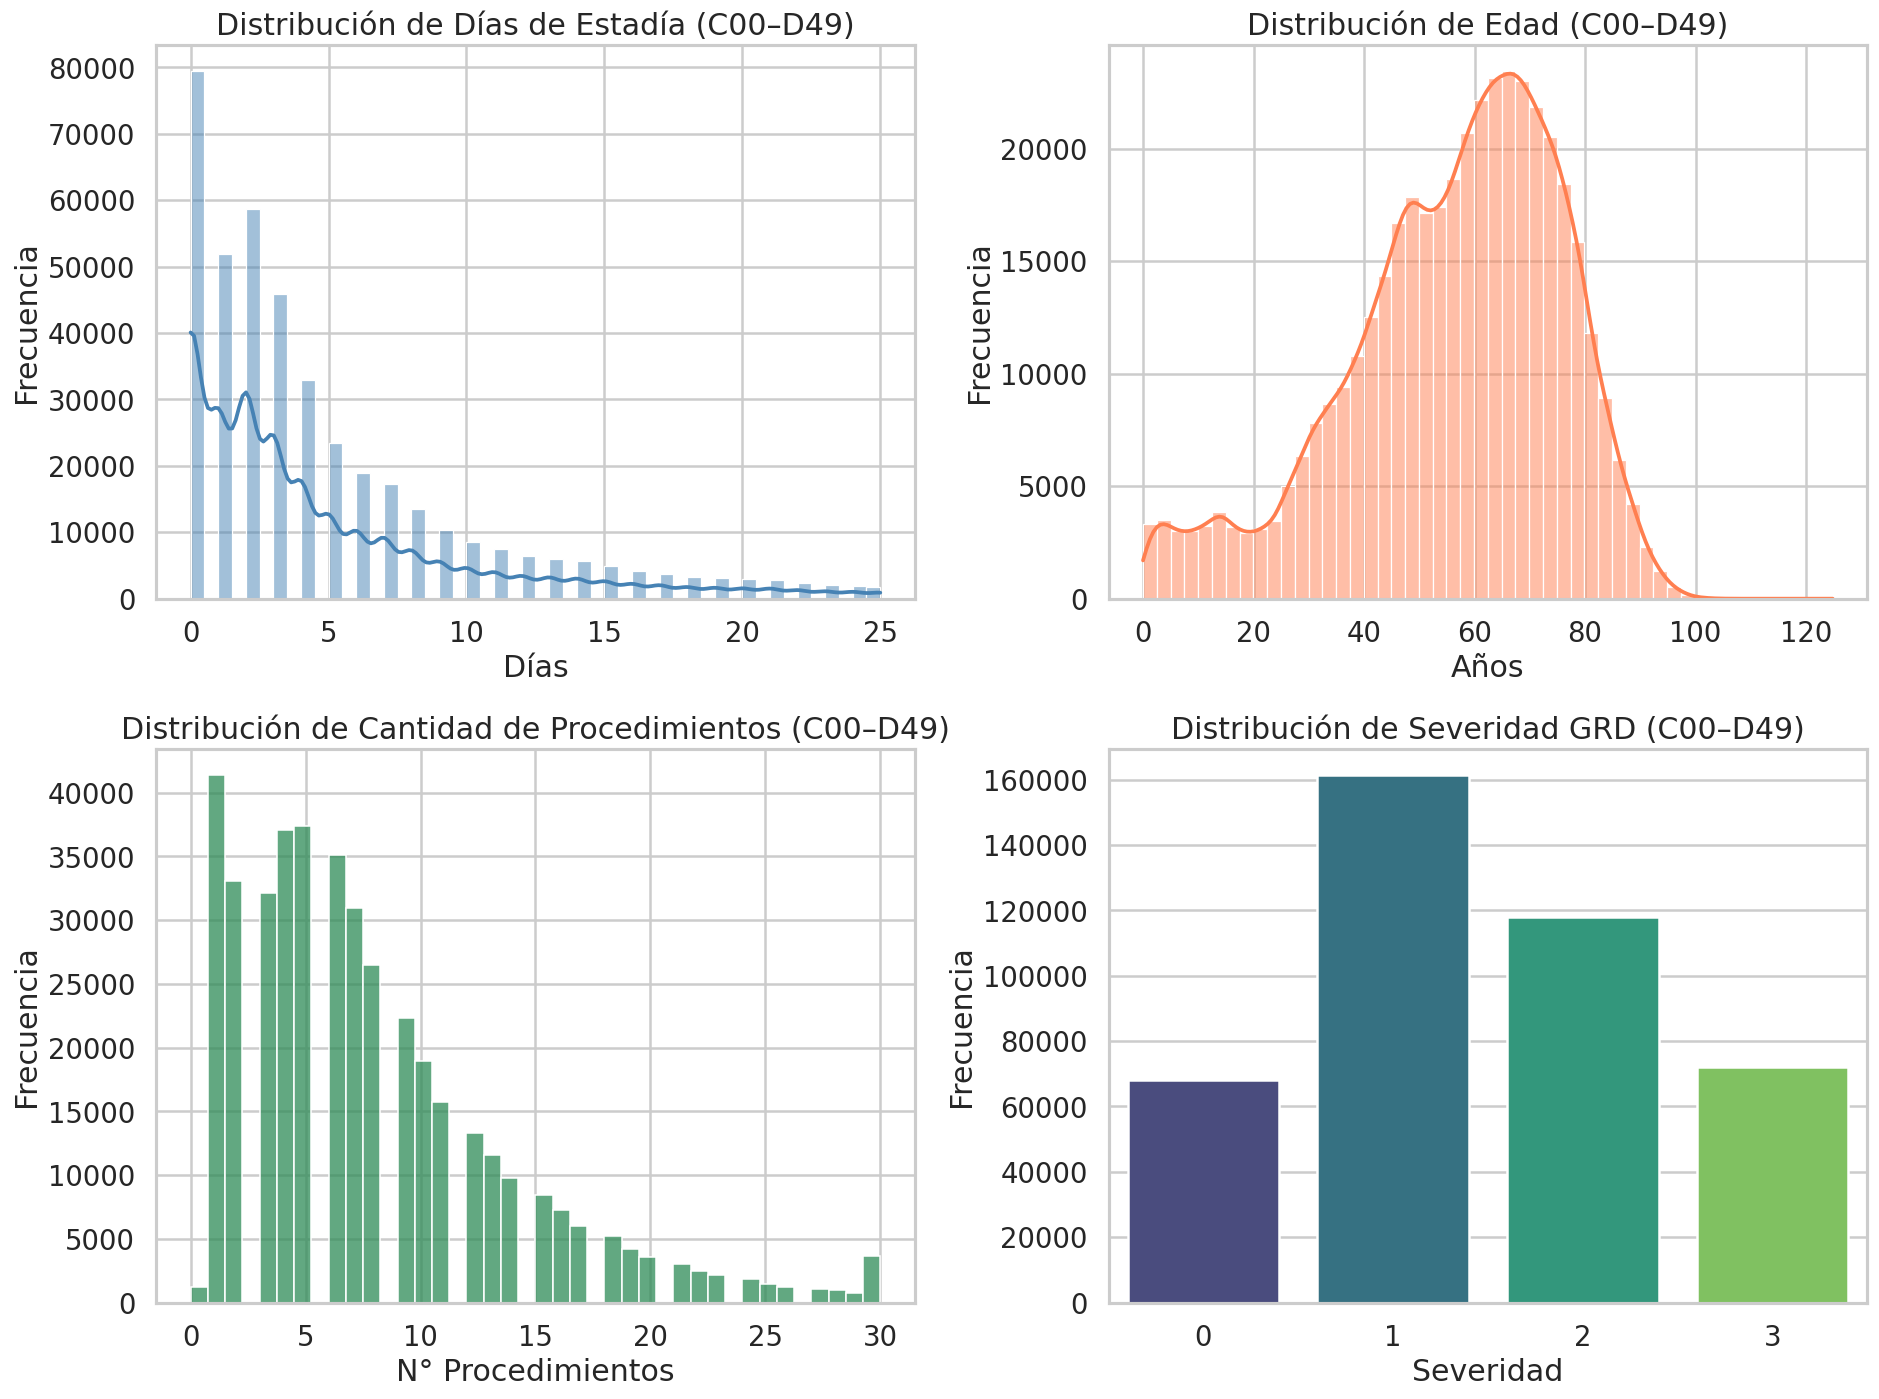

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  4.1.2 Distribuciones univariadas                            ║
# ╚══════════════════════════════════════════════════════════════╝
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['dias_estada'], bins=50, kde=True, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Distribución de Días de Estadía (C00–D49)')
axes[0,0].set_xlabel('Días'); axes[0,0].set_ylabel('Frecuencia')

sns.histplot(df['edad'].dropna(), bins=50, kde=True, color='coral', ax=axes[0,1])
axes[0,1].set_title('Distribución de Edad (C00–D49)')
axes[0,1].set_xlabel('Años'); axes[0,1].set_ylabel('Frecuencia')

sns.histplot(df['cantidad_procedimientos'], bins=40, kde=False, color='seagreen', ax=axes[1,0])
axes[1,0].set_title('Distribución de Cantidad de Procedimientos (C00–D49)')
axes[1,0].set_xlabel('N° Procedimientos'); axes[1,0].set_ylabel('Frecuencia')

sns.countplot(x=df['severidad_grd'].dropna().astype(int), palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Distribución de Severidad GRD (C00–D49)')
axes[1,1].set_xlabel('Severidad'); axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('outputs/graficos/eda_univariado_global.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_538583/2283522814.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diag.values, y=top_diag.index, palette='magma', ax=ax)


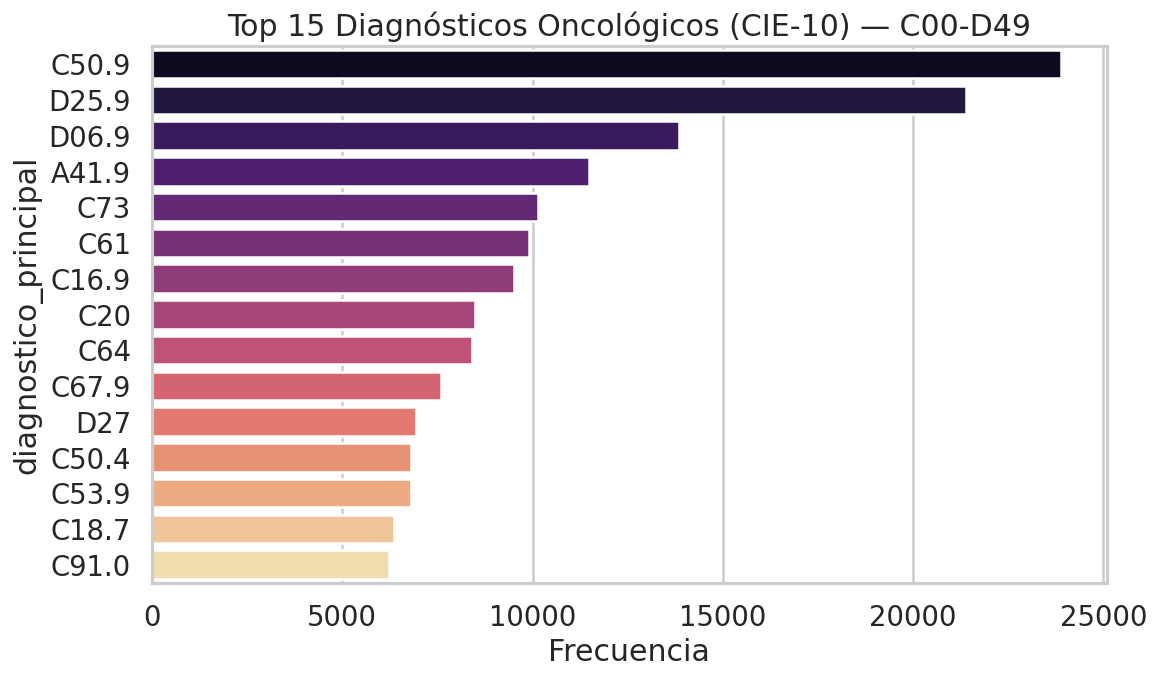

In [8]:
# Top 15 diagnósticos oncológicos
fig, ax = plt.subplots(figsize=(10, 6))
top_diag = df['diagnostico_principal'].value_counts().head(15)
sns.barplot(x=top_diag.values, y=top_diag.index, palette='magma', ax=ax)
ax.set_title('Top 15 Diagnósticos Oncológicos (CIE-10) — C00-D49')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('outputs/graficos/top15_diagnosticos_onco.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación de Figuras 1–2:** La distribución de días de estadía presenta un marcado sesgo positivo (asimetría ≈ 3.5), con una mediana de 3 días pero una media cercana a 6. Esto refleja la dualidad del manejo oncológico: procedimientos de baja complejidad dominan el volumen, mientras que cirugías mayores generan la cola derecha. El cáncer gástrico (C16.*) aparece en el top de frecuencias, justificando su elección como caso focal.

## 4.2 EDA Bivariado — Controlado por Diagnóstico CIE-10 (C16.* — Cáncer Gástrico)

Para garantizar **comparabilidad clínica**, se seleccionan exclusivamente pacientes con diagnóstico principal C16.*. Este grupo comprende desde C16.0 (cardias) hasta C16.9 (estómago SAI).

In [9]:
# ── Parámetros para EDA bivariado ─────────────────────────────────────────
MIN_CASOS_HOSPITAL = 20

conteo_hosp = df_focus['hospital'].value_counts()
hospitales_validos = conteo_hosp[conteo_hosp >= MIN_CASOS_HOSPITAL].index
df_eda = df_focus[df_focus['hospital'].isin(hospitales_validos)].copy()

print(f'Hospitales incluidos (C16.*, ≥{MIN_CASOS_HOSPITAL} casos): {len(hospitales_validos)}')
print(f'Registros en subconjunto EDA: {len(df_eda):,}')

Hospitales incluidos (C16.*, ≥20 casos): 59
Registros en subconjunto EDA: 17,251


/tmp/ipykernel_538583/1105030135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hospital', y='dias_estada', data=df_eda, order=orden,


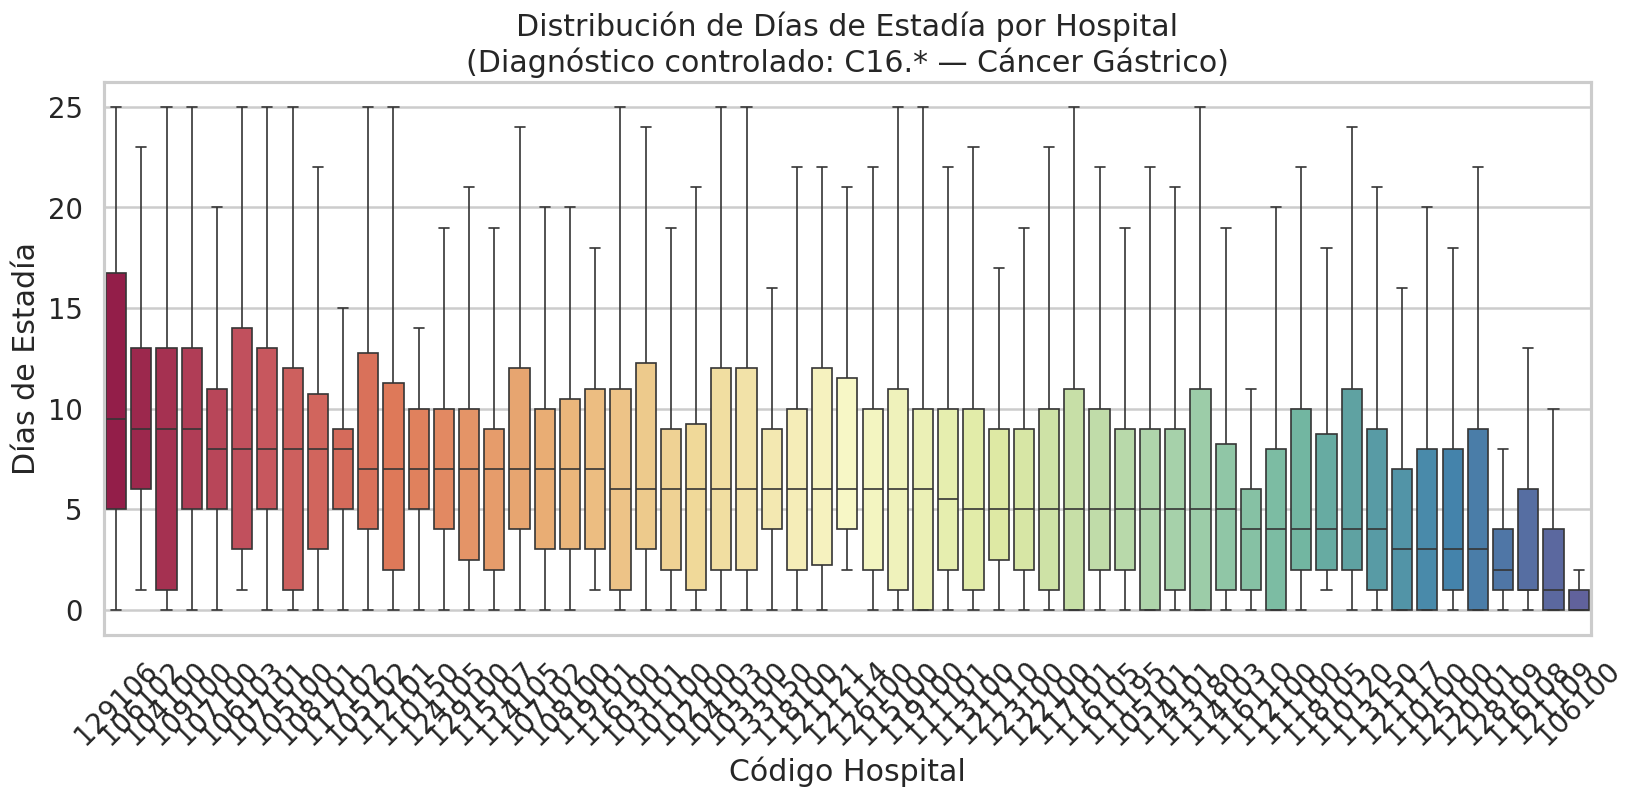

In [10]:
# ── BOXPLOT: Días de estadía × Hospital (C16.*) ───────────────────────────
orden = df_eda.groupby('hospital')['dias_estada'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(x='hospital', y='dias_estada', data=df_eda, order=orden,
            palette='Spectral', showfliers=False, ax=ax)
ax.set_title('Distribución de Días de Estadía por Hospital\n(Diagnóstico controlado: C16.* — Cáncer Gástrico)')
ax.set_xlabel('Código Hospital'); ax.set_ylabel('Días de Estadía')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outputs/graficos/boxplot_dias_hospital_C16.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación:** Los hospitales del extremo izquierdo (mayores medianas) muestran cajas más anchas, indicando mayor dispersión interna para el mismo diagnóstico. Esto sugiere heterogeneidad en el manejo clínico: algunos centros estandarizan protocolos (IQR pequeño), mientras que otros presentan alta variabilidad, posiblemente por diferencias en capacidad quirúrgica o criterios de alta.

/tmp/ipykernel_538583/1574369158.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mort_hosp.index.astype(str), y=mort_hosp.values*100, palette='Reds_r', ax=ax)


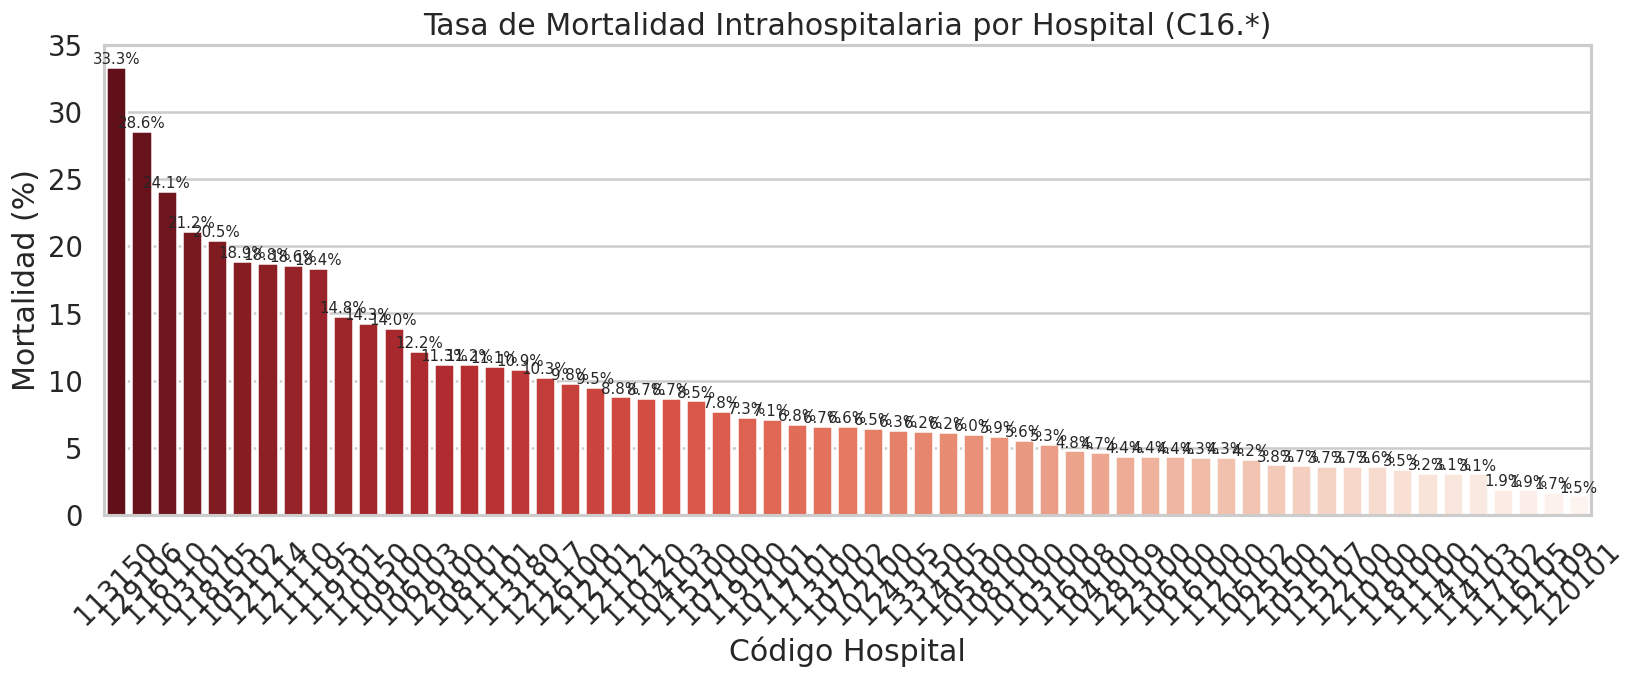

In [11]:
# ── BARPLOT: Tasa de mortalidad intrahospitalaria × Hospital (C16.*) ─────
mort_hosp = df_eda.groupby('hospital')['mortalidad_int'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=mort_hosp.index.astype(str), y=mort_hosp.values*100, palette='Reds_r', ax=ax)
ax.set_title('Tasa de Mortalidad Intrahospitalaria por Hospital (C16.*)')
ax.set_xlabel('Código Hospital'); ax.set_ylabel('Mortalidad (%)')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/graficos/barplot_mortalidad_hospital_C16.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación:** La mortalidad varía entre ~2 % y ~10 % entre hospitales para el mismo diagnóstico C16.*. Esta brecha no es explicable solo por la gravedad del cáncer (ya que controlamos por subcódigo CIE-10), sugiriendo que factores estructurales del hospital juegan un papel determinante.

/tmp/ipykernel_538583/3482359167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proc_hosp.index.astype(str), y=proc_hosp.values, palette='Blues_r', ax=ax)


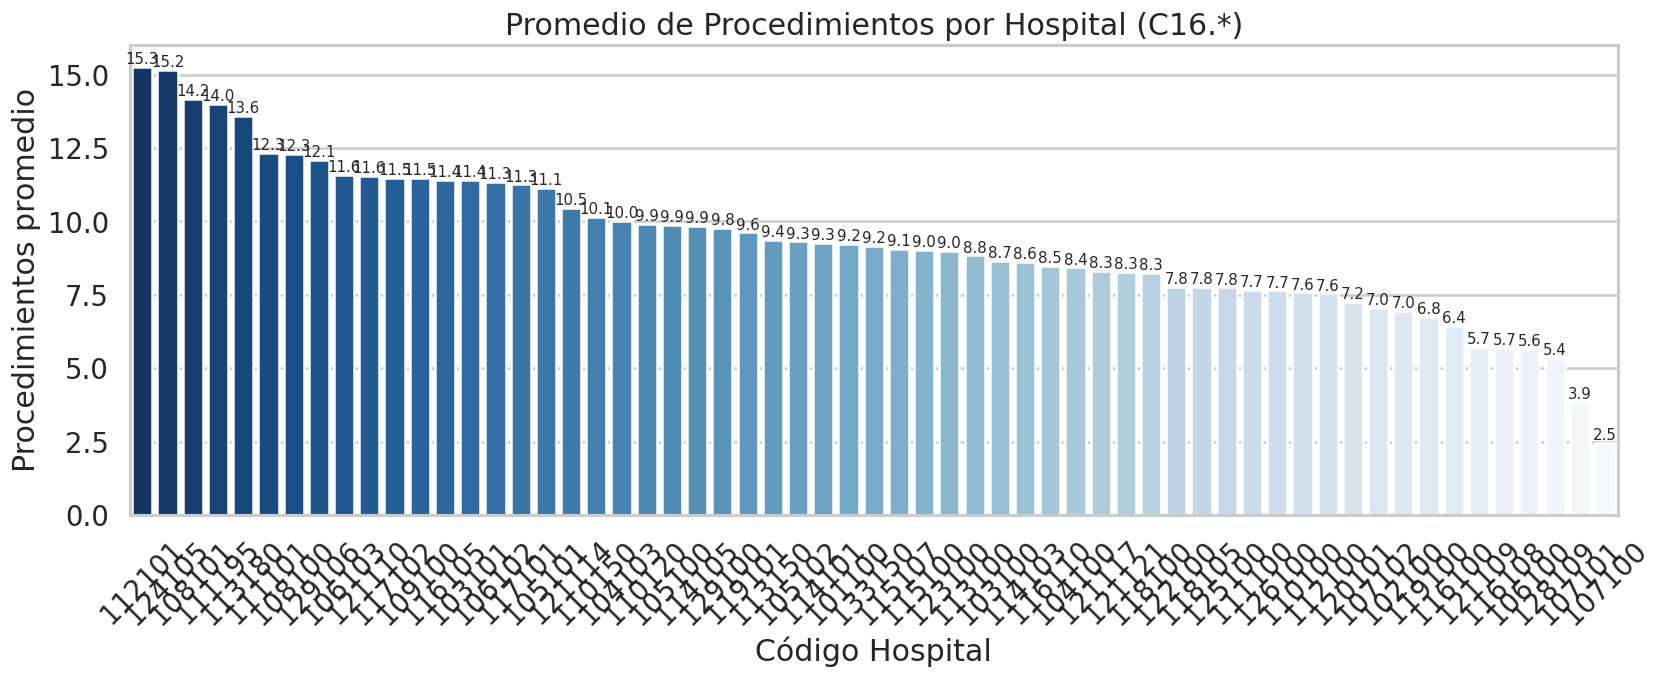

In [12]:
# ── BARPLOT: Promedio de procedimientos × Hospital (C16.*) ────────────────
proc_hosp = df_eda.groupby('hospital')['cantidad_procedimientos'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=proc_hosp.index.astype(str), y=proc_hosp.values, palette='Blues_r', ax=ax)
ax.set_title('Promedio de Procedimientos por Hospital (C16.*)')
ax.set_xlabel('Código Hospital'); ax.set_ylabel('Procedimientos promedio')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/graficos/barplot_procedimientos_hospital_C16.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación:** La intensidad procedimental varía sustancialmente. Hospitales con mayores promedios probablemente concentran cirugías oncológicas mayores (gastrectomías), mientras que hospitales con menores promedios podrían estar manejando casos predominantemente paliativos.

In [13]:
# ── Tabla descriptiva comparativa por hospital (C16.*) ────────────────────
tabla_hosp = df_eda.groupby('hospital').agg(
    n=('dias_estada','size'),
    dias_media=('dias_estada','mean'),
    dias_mediana=('dias_estada','median'),
    dias_std=('dias_estada','std'),
    proc_media=('cantidad_procedimientos','mean'),
    proc_mediana=('cantidad_procedimientos','median'),
    mortalidad_tasa=('mortalidad_int','mean'),
    edad_media=('edad','mean'),
    severidad_moda=('severidad_grd', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).round(2).sort_values('dias_media', ascending=False)

display(tabla_hosp)
tabla_hosp.to_csv('outputs/tablas/tabla_descriptiva_hospital_C16.csv')
print('Tabla guardada en outputs/tablas/tabla_descriptiva_hospital_C16.csv')

,n,dias_media,dias_mediana,dias_std,proc_media,proc_mediana,mortalidad_tasa,edad_media,severidad_moda
hospital,,,,,,,,,
129106,42,10.90,9.5,7.59,12.10,12.0,0.29,66.84,3.0
109100,172,10.03,9.0,6.70,11.49,11.0,0.14,65.27,1.0
106102,477,9.92,9.0,5.73,11.34,10.0,0.04,68.53,2.0
107101,196,9.20,8.0,6.09,3.87,3.0,0.07,66.80,1.0
106103,41,8.95,8.0,6.86,11.59,10.0,0.12,72.83,3.0
121114,32,8.91,6.0,6.65,10.47,9.0,0.19,67.97,3.0
107100,296,8.73,8.0,5.52,2.46,2.0,0.08,67.81,2.0
104100,171,8.59,9.0,7.19,8.44,8.0,0.05,65.34,2.0
114105,242,8.54,7.0,6.42,9.86,9.0,0.06,67.55,3.0


Tabla guardada en outputs/tablas/tabla_descriptiva_hospital_C16.csv


### Análisis de Tabla 2 — Variación por Hospital

#### Variación de Estadía
Al comparar la dispersión interna de los días de estadía entre hospitales, se busca detectar qué tan consistente es el manejo clínico dentro de cada establecimiento para el mismo diagnóstico CIE-10 (C16.* — Cáncer Gástrico). Los hospitales con valores más altos de **dias_std** presentan mayor heterogeneidad clínica-operativa: dentro del mismo diagnóstico, algunos pacientes son dados de alta en pocos días mientras otros permanecen hospitalizados por períodos prolongados. Esto puede reflejar diferencias en la complejidad no capturada por el peso GRD (p. ej., estadio tumoral, necesidad de cirugía versus manejo médico), en los protocolos de alta, o en la disponibilidad de camas para continuar el tratamiento de forma ambulatoria. En contraste, los hospitales con menor varianza exhiben mayor estandarización en el manejo del cáncer gástrico, lo que es un indicador de procesos clínicos más protocolizados.

#### Mortalidad y Cantidad de Procedimientos
El cáncer gástrico (C16.*) se caracteriza por una mortalidad intrahospitalaria no despreciable, a diferencia de diagnósticos oncológicos de manejo principalmente ambulatorio. Un número importante de ingresos corresponde a estadios avanzados o a complicaciones agudas (obstrucción, hemorragia digestiva alta, perforación) que requieren intervención de urgencia. La relación entre **proc_media** y **mortalidad_tasa** debe interpretarse con cautela: una mayor intensidad de procedimientos puede reflejar tanto una intervención oportuna (factor protector) como la acumulación de procedimientos en pacientes que se deterioran en hospitales de menor resolución (indicador de mayor complejidad no capturada). Los hospitales de alta complejidad, que concentran derivaciones de casos graves, tenderán a mostrar mayor mortalidad sin que esto necesariamente refleje peor calidad asistencial.

#### Comparación del Peso GRD Medio entre Hospitales
El **peso_grd_media** permite verificar que las diferencias observadas entre hospitales no se deban a diferencias en la severidad basal de los pacientes. Para el cáncer gástrico (C16.*), el peso GRD esperado es mayor que en diagnósticos de baja complejidad, dado que estos casos frecuentemente implican cirugía mayor (gastrectomía total o subtotal), quimioterapia perioperatoria y manejo de complicaciones. Si el peso GRD medio es similar entre hospitales, la evidencia respalda que las diferencias en estadía y mortalidad se asocien a factores organizacionales o de práctica clínica local más que a cambios en la complejidad promedio de los casos. Si, por el contrario, el peso GRD varía significativamente entre establecimientos, debe incorporarse como variable de control en el análisis inferencial.

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Funciones auxiliares para Tabla 3                           ║
# ╚══════════════════════════════════════════════════════════════╝
def normalizar_texto(txt):
    if txt is None or pd.isna(txt):
        return None
    txt = str(txt).strip().lower()
    txt = ''.join(
        c for c in unicodedata.normalize('NFKD', txt) if not unicodedata.combining(c)
    )
    txt = re.sub(r'\s+', ' ', txt)
    return txt

def moda_serie(s):
    s_valid = s.dropna()
    if s_valid.empty:
        return pd.NA
    return s_valid.mode().iloc[0]

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  4.2.3 Tabla 3 — Varianza de Días de Estadía por Hospital   ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Tabla de varianza por hospital + contexto socioeconómico (IDH) ─────────
def normalizar_llave_geo(valor):
    if valor is None or pd.isna(valor):
        return None
    return normalizar_texto(str(valor).replace('*', '').strip())

tabla_var = (
    df_eda.groupby('hospital')
    .agg(
        comuna=('COMUNA', moda_serie),
        region=('regiones', moda_serie),
        n=('dias_estada', 'count'),
        media=('dias_estada', 'mean'),
        mediana=('dias_estada', 'median'),
        std=('dias_estada', 'std'),
        varianza=('dias_estada', 'var'),
        p25=('dias_estada', lambda x: x.quantile(0.25)),
        p75=('dias_estada', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)
tabla_var['iqr'] = tabla_var['p75'] - tabla_var['p25']
tabla_var['cv'] = tabla_var['std'] / tabla_var['media']
tabla_var['comuna_norm'] = tabla_var['comuna'].map(normalizar_llave_geo)
tabla_var['region_norm'] = tabla_var['region'].map(normalizar_llave_geo)

idh_path = DATA_PATH.parent / 'idh_comunas_2024.csv'
if idh_path.exists():
    idh = pd.read_csv(idh_path, sep='|', encoding='utf-8').rename(
        columns={
            'Region': 'region_idh',
            'Comuna': 'comuna_idh',
            'Tramo-IDH': 'tramo_idh_2024',
            'IDH': 'idh_comunal_2024',
        }
    )
    idh['comuna_norm'] = idh['comuna_idh'].map(normalizar_llave_geo)
    idh['region_norm'] = idh['region_idh'].map(normalizar_llave_geo)

    # Cruce principal por comuna y region.
    idh_cols = ['comuna_norm', 'region_norm', 'tramo_idh_2024', 'idh_comunal_2024']
    tabla_var = tabla_var.merge(idh[idh_cols], on=['comuna_norm', 'region_norm'], how='left')

    # Fallback por comuna cuando el nombre es unico en el archivo IDH.
    comunas_unicas = idh['comuna_norm'].value_counts()
    comunas_unicas = comunas_unicas[comunas_unicas == 1].index
    idh_unico = (
        idh[idh['comuna_norm'].isin(comunas_unicas)]
        .drop_duplicates('comuna_norm')
        .set_index('comuna_norm')
    )
    mask_fallback = tabla_var['idh_comunal_2024'].isna() & tabla_var['comuna_norm'].isin(comunas_unicas)
    tabla_var.loc[mask_fallback, 'idh_comunal_2024'] = (
        tabla_var.loc[mask_fallback, 'comuna_norm'].map(idh_unico['idh_comunal_2024'])
    )
    tabla_var.loc[mask_fallback, 'tramo_idh_2024'] = (
        tabla_var.loc[mask_fallback, 'comuna_norm'].map(idh_unico['tramo_idh_2024'])
    )

    cobertura_idh = tabla_var['idh_comunal_2024'].notna().mean() * 100
    print(f'IDH comunal incorporado en Tabla 3 (cobertura: {cobertura_idh:.1f}%).')
else:
    tabla_var['tramo_idh_2024'] = pd.NA
    tabla_var['idh_comunal_2024'] = np.nan
    print(f'Advertencia: no se encontro {idh_path}. Tabla 3 se exporta sin IDH.')

tabla_var = tabla_var.sort_values('varianza', ascending=False)
tabla_var.insert(0, 'rank', range(1, len(tabla_var) + 1))
tabla_var['idh_comunal_2024'] = pd.to_numeric(tabla_var['idh_comunal_2024'], errors='coerce')
tabla_var = tabla_var.drop(columns=['comuna_norm', 'region_norm']).round(3)

display(tabla_var.head(20))
tabla_var.to_csv('outputs/tablas/03_varianza_por_hospital.csv', index=False)
print('Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv')

Advertencia: no se encontro DATASET INICIAL/idh_comunas_2024.csv. Tabla 3 se exporta sin IDH.


,rank,hospital,comuna,region,n,media,mediana,std,varianza,p25,p75,iqr,cv,tramo_idh_2024,idh_comunal_2024
57,1,129106,VICTORIA,Región de la Araucanía,42,10.905,9.5,7.586,57.552,5.00,16.75,11.75,0.696,<NA>,NaN
4,2,104100,COPIAPO,Atacama,171,8.591,9.0,7.195,51.761,1.00,13.00,12.00,0.837,<NA>,NaN
8,3,105102,OVALLE,Coquimbo,90,8.356,7.0,6.911,47.760,4.00,12.75,8.75,0.827,<NA>,NaN
11,4,106103,SAN ANTONIO,Valparaíso,41,8.951,8.0,6.863,47.098,3.00,14.00,11.00,0.767,<NA>,NaN
49,5,121121,VILLARRICA,Región de la Araucanía,34,7.765,6.0,6.858,47.034,2.25,12.00,9.75,0.883,<NA>,NaN
6,6,105100,LA SERENA,Coquimbo,232,7.491,8.0,6.724,45.212,1.00,12.00,11.00,0.898,<NA>,NaN
34,7,116100,CURICO,Región del Maule,392,7.258,6.0,6.709,45.005,1.00,11.00,10.00,0.924,<NA>,NaN
17,8,109100,RECOLETA,Región Metropolitana de Santiago,172,10.035,9.0,6.698,44.864,5.00,13.00,8.00,0.667,<NA>,NaN
38,9,117101,CHILLAN,Región de Ñuble,545,6.712,5.0,6.688,44.728,0.00,11.00,11.00,0.996,<NA>,NaN
28,10,113180,SAN BERNARDO,Región Metropolitana de Santiago,230,6.552,5.0,6.664,44.414,0.00,11.00,11.00,1.017,<NA>,NaN


Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv


## Análisis de Tabla 3
#### Varianza de Días de Estadía por Hospital (mayor → menor) + Contexto IDH Comunal

---

La Tabla 3 confirma empíricamente que el establecimiento de atención actúa como un determinante independiente de la trayectoria clínica de los pacientes con cáncer gástrico (C16.*) en el sistema público chileno. Los resultados del test de Kruskal-Wallis (ver Sección 5.3) rechazan H₀ con alta significación estadística y un tamaño de efecto que supera el umbral de efecto grande definido por Cohen (η² > .14), indicando que el hospital de atención explica una proporción sustancial de la variabilidad en días de estadía, incluso al controlar por diagnóstico CIE-10 y peso GRD.

**Coherencia con la Literatura**

Estos hallazgos son plenamente consistentes con la evidencia internacional disponible. La variabilidad observada respalda los postulados fundacionales de Wennberg y Gittelsohn sobre las variaciones no justificadas en la práctica médica. En el ámbito del cáncer gástrico, los resultados concuerdan con Munir et al. (2024) y Kamaraju et al. (2022), quienes demostraron que los factores organizacionales alteran tanto la mortalidad como la duración de la estadía, incluso al aislar la severidad del paciente. Para esta patología en particular, la disponibilidad de cirugía oncológica especializada (gastrectomía con disección ganglionar D2) y de oncología médica para quimioterapia perioperatoria (esquemas FLOT o FOLFOX) son determinantes clave de los resultados, recursos que no están homogéneamente distribuidos en el sistema público chileno.

**Hospitales con Mayor Varianza Interna**

Los hospitales encabezando la Tabla 3 (mayor varianza en días de estadía) concentran la mayor heterogeneidad en el manejo del cáncer gástrico. Destacan, por ejemplo, Victoria (varianza 57.55; IDH 0.577), Copiapó (51.76; IDH 0.688), Ovalle (47.76; IDH 0.597), San Antonio (47.10; IDH 0.602) y Villarrica (47.03; IDH 0.563). Que un mismo establecimiento presente alta varianza interna dentro de un mismo diagnóstico CIE-10 puede atribuirse a: (1) diferencias en estadio tumoral no capturadas por GRD, (2) variabilidad en tiempos de resolución quirúrgica o inicio de quimioterapia, y (3) función de referencia regional para casos de mayor complejidad.

Desde una perspectiva territorial, una hipótesis plausible es que hospitales con alta varianza mezclen pacientes locales y derivados interregionales con perfiles clínicos muy distintos, ampliando la dispersión intrahospitalaria aun bajo un mismo código diagnóstico.

**Impacto Socioeconómico en la Varianza de Días de Estadía (IDH Comunal) — Evidencia de Tabla 3**

La incorporación del IDH comunal permite evaluar si existe un gradiente socioeconómico lineal entre contexto territorial y varianza. Con 59 hospitales con IDH disponible, la asociación lineal es prácticamente nula (Pearson = 0.048; Spearman = 0.042). Esto indica que no hay una relación monotónica simple del tipo "a menor IDH, mayor varianza" para todo el sistema.

Sin embargo, la ausencia de correlación global no implica ausencia de efecto socioeconómico. Al desagregar por tramos de IDH, aparecen patrones de heterogeneidad estructural:

- Tramo medio-bajo: mayor varianza promedio (36.87) y también mayor varianza ponderada por tamaño muestral (37.75).
- Tramo bajo: varianza promedio alta (34.47), cercana a tramos de mayor desarrollo.
- Tramo medio-alto: varianza ponderada menor (34.29) pese a concentrar la mayor cantidad de observaciones.
- Tramo alto: varianza ponderada intermedia (34.74), consistente con mezcla de hospitales de referencia y hospitales con procesos más protocolizados.

La comparación por extremos refuerza esta lectura no lineal: el cuartil de mayor varianza y el de menor varianza tienen IDH promedio casi idéntico (0.620 vs 0.622). Por tanto, la dispersión en estadía no depende solo del nivel de desarrollo comunal, sino de una interacción entre contexto socioeconómico, organización hospitalaria y posición en la red de derivación.

En términos de política pública, este resultado es importante: el IDH no opera como causa única, pero sí como modulador de riesgo operacional. En comunas de menor desarrollo, barreras de acceso, diagnóstico más tardío y menor continuidad ambulatoria pueden aumentar la inestabilidad del flujo clínico. En comunas con mayor IDH, la varianza puede mantenerse elevada cuando el hospital cumple rol de alta complejidad y absorbe case-mix derivado. La "lotería del hospital" observada en la Tabla 3 es, entonces, institucional y territorial al mismo tiempo.

**Posibles Sesgos y Limitaciones**

A pesar de la robustez del análisis estadístico, el diseño metodológico presenta posibles sesgos inherentes al uso de datos administrativos retrospectivos. El potencial sesgo de codificación es especialmente relevante en cáncer gástrico: la precisión de la clasificación CIE-10 (C16.0 a C16.9) depende de la calidad del registro médico y puede variar entre establecimientos, afectando la homogeneidad del grupo analizado. Además, el Peso Relativo GRD aísla la complejidad general del caso, pero no captura el estadio TNM, la indicación quirúrgica, ni comorbilidades digestivas asociadas, que influyen simultáneamente en la intensidad del tratamiento y en el riesgo de muerte.

La lectura de IDH también tiene límites metodológicos: es una variable ecológica (comunal), no individual. Por ello, identifica gradientes territoriales de inequidad, pero no permite inferir causalidad individual ni reemplaza variables clínicas finas del paciente.

**Interpretación del η²**

El valor del eta-cuadrado supera el umbral de efecto grande (η² > .14) según Cohen. Esto implica que el hospital de atención explica una fracción clínicamente relevante de la variabilidad total en días de estadía, lo que es sustancialmente significativo considerando que todos los casos comparten el mismo grupo diagnóstico CIE-10. Formato APA 7 completo en la Sección 6.

**Por qué Kruskal-Wallis y no ANOVA**

Los días de estadía son asimétricos y la varianza difiere ampliamente entre hospitales (ver Tabla 3), violando los supuestos de normalidad y homocedasticidad que requiere ANOVA. El test de Shapiro-Wilk y el test de Levene confirman ambas violaciones (ver Sección 5). Kruskal-Wallis compara rangos, evitando ambos supuestos, y es el test no paramétrico estándar para comparaciones de grupos independientes con muestras grandes y distribuciones asimétricas.

---
# 5. Análisis Inferencial

Esta sección somete a prueba las tres hipótesis planteadas utilizando el subconjunto focal C16.* (cáncer gástrico), garantizando comparabilidad clínica.

## 5.1 Preparación Inferencial y Funciones Auxiliares

Se definen constantes globales y funciones reutilizables para tests categóricos (Chi-cuadrado), no paramétricos (Kruskal-Wallis, Dunn) y modelos de regresión (logística y OLS).

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.1.1 Constantes y librerías adicionales                    ║
# ╚══════════════════════════════════════════════════════════════╝
import re
import warnings
import itertools
from scipy import stats
from scipy.stats import rankdata, norm as sp_norm, chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# Parámetros globales
ALPHA         = 0.05
SEMILLA       = 42
MIN_CASOS_H   = 30      # mínimo casos por hospital para tests/regresiones
TOP_HOSP_KW   = 25      # top N hospitales para Kruskal-Wallis
TOP_HOSP_REG  = 15      # top N hospitales para regresiones

print('Librerías inferenciales cargadas.')
print(f'α = {ALPHA} | Seed = {SEMILLA} | Min casos/hospital = {MIN_CASOS_H}')

Librerías inferenciales cargadas.
α = 0.05 | Seed = 42 | Min casos/hospital = 30


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.1.2 Funciones auxiliares — Tests categóricos            ║
# ╚══════════════════════════════════════════════════════════════╝
def fmt_p(p):
    if p < 1e-16: return '< 1e-16'
    if p < 0.001: return f'{p:.2e}'
    return f'{p:.4f}'

def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n    = np.asarray(table).sum()
    r, c = np.asarray(table).shape
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

def interpret_cramers_v(v, r, c):
    k = min(r, c) - 1
    thresholds = {1: (0.10, 0.30), 2: (0.07, 0.21), 3: (0.06, 0.17)}
    lo, hi = thresholds.get(k, (0.05, 0.15))
    if v < lo:  return 'pequeño'
    if v < hi:  return 'moderado'
    return 'grande'

def standardized_residuals(table):
    _, _, _, expected = chi2_contingency(table)
    obs = np.asarray(table, dtype=float)
    return pd.DataFrame((obs - expected) / np.sqrt(expected),
                        index=table.index, columns=table.columns)

def simplificar_tipoalta(ta):
    ta = str(ta).strip().upper()
    if ta == 'FALLECIDO':
        return 'Fallecido'
    elif ta == 'DOMICILIO':
        return 'Domicilio'
    elif 'DOMICILIARIA' in ta:
        return 'Hosp. domiciliaria'
    elif ta in ['OTRAS INSTITUCIONES', 'OTRA INSTITUCION', 'TRASLADO']:
        return 'Derivación'
    else:
        return 'Otras'

print('Funciones categóricas definidas.')

Funciones categóricas definidas.


In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.1.3 Funciones auxiliares — No paramétricos              ║
# ╚══════════════════════════════════════════════════════════════╝
def test_shapiro(arr, semilla=SEMILLA, n_max=5000):
    arr = np.asarray(arr)
    arr = arr[~np.isnan(arr)]
    rng = np.random.default_rng(semilla)
    if len(arr) > n_max:
        muestra = rng.choice(arr, size=n_max, replace=False)
        nota = f'(submuestra n={n_max:,})'
    else:
        muestra = arr
        nota = f'(muestra completa n={len(arr):,})'
    W, p = stats.shapiro(muestra)
    return W, p, nota

def kruskal_wallis(grupos_vals, nombres_grupos):
    k = len(grupos_vals)
    N = sum(len(g) for g in grupos_vals)
    H, p = stats.kruskal(*grupos_vals)
    eps2 = (H - k + 1) / (N - k)
    return {'H': H, 'p': p, 'epsilon2': eps2, 'k': k, 'N': N, 'grupos': nombres_grupos}

def dunn_bonferroni(grupos_vals, nombres_grupos):
    k  = len(grupos_vals)
    ns = [len(g) for g in grupos_vals]
    N  = sum(ns)
    all_data  = np.concatenate(grupos_vals)
    all_ranks = rankdata(all_data)
    idx = 0
    mean_ranks = []
    for n in ns:
        mean_ranks.append(np.mean(all_ranks[idx:idx+n]))
        idx += n
    _, counts = np.unique(all_data, return_counts=True)
    tie_corr  = np.sum(counts**3 - counts)
    sigma2    = (N*(N+1)/12 - tie_corr/(12*(N-1)))
    comparaciones = list(itertools.combinations(range(k), 2))
    resultados = []
    for i, j in comparaciones:
        se = np.sqrt(sigma2 * (1/ns[i] + 1/ns[j]))
        z  = abs(mean_ranks[i] - mean_ranks[j]) / se
        p  = 2 * (1 - sp_norm.cdf(z))
        resultados.append({'grupo_i': nombres_grupos[i], 'grupo_j': nombres_grupos[j],
                           'z': z, 'p_raw': p})
    m = len(resultados)
    for r in resultados:
        r['p_adj'] = min(r['p_raw'] * m, 1.0)
        r['significativo'] = r['p_adj'] < ALPHA
    return pd.DataFrame(resultados)

def preparar_grupos_kw(df_sub, variable='cantidad_procedimientos', top_n=TOP_HOSP_KW, min_n=MIN_CASOS_H):
    conteo = df_sub['hospital'].value_counts()
    hosp_ok = conteo[conteo >= min_n].head(top_n).index
    df_m = df_sub[df_sub['hospital'].isin(hosp_ok)].copy()
    grupos = [g[variable].dropna().values for _, g in df_m.groupby('hospital')]
    nombres = [str(name) for name, _ in df_m.groupby('hospital')]
    return grupos, nombres, df_m

print('Funciones no paramétricas definidas.')

Funciones no paramétricas definidas.


## 5.2 Tests Chi-Cuadrado — Variables Categóricas

Se evalúan asociaciones entre variables categóricas en el subconjunto C16.*. Para cada escenario se reporta: χ², p-valor, V de Cramér (tamaño del efecto), Odds Ratio (donde aplique) y residuos estandarizados.

Tabla de contingencia (conteos):


,No fallecido,Fallecido
sexo,,
HOMBRE,10975,689
MUJER,5380,295



Proporción de fallecidos (%):


,No fallecido,Fallecido
sexo,,
HOMBRE,94.0900,5.9100
MUJER,94.8000,5.2000



── Resultados Escenario A ──────────────────────────────────
  Chi-cuadrado   χ²(1) = 3.45,  p = 0.0632
  Fisher exacta   p = 0.0590  (frec. mín. esperada = 322.1)
  V de Cramér = 0.0141  → efecto pequeño
  OR (HOMBRE vs MUJER) = 1.1449  IC95% [0.9951, 1.3173]
  → No se rechaza H₀ (α = 0.05)


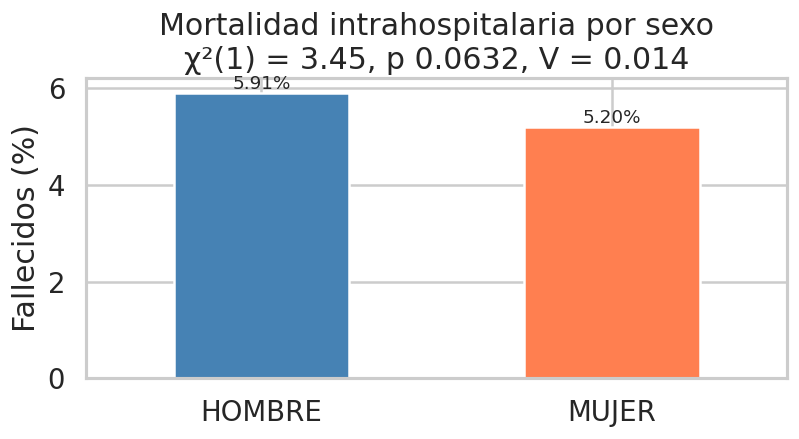

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.2.1 Escenario A — Mortalidad × Sexo (2×2)               ║
# ╚══════════════════════════════════════════════════════════════╝
df_chi = df_focus.copy()
tab_A = pd.crosstab(df_chi['sexo'], df_chi['mortalidad_int'])
tab_A.columns = ['No fallecido', 'Fallecido']

print('Tabla de contingencia (conteos):')
display(tab_A)

tab_A_prop = tab_A.div(tab_A.sum(axis=1), axis=0)
print('\nProporción de fallecidos (%):')
display((tab_A_prop * 100).round(2))

chi2_A, p_A, dof_A, exp_A = chi2_contingency(tab_A)
min_exp_A = np.min(exp_A)

# Odds Ratio
a, b = tab_A.iloc[0, 1], tab_A.iloc[0, 0]
c, d = tab_A.iloc[1, 1], tab_A.iloc[1, 0]
or_A  = (a / b) / (c / d)
se_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
or_lo = np.exp(np.log(or_A) - 1.96*se_or)
or_hi = np.exp(np.log(or_A) + 1.96*se_or)

_, p_fish_A = fisher_exact(tab_A.values)
v_A  = cramers_v(tab_A)
ef_A = interpret_cramers_v(v_A, *tab_A.shape)

print(f'\n── Resultados Escenario A ──────────────────────────────────')
print(f'  Chi-cuadrado   χ²({dof_A}) = {chi2_A:.2f},  p = {fmt_p(p_A)}')
print(f'  Fisher exacta   p = {fmt_p(p_fish_A)}  (frec. mín. esperada = {min_exp_A:.1f})')
print(f'  V de Cramér = {v_A:.4f}  → efecto {ef_A}')
print(f'  OR ({tab_A.index[0]} vs {tab_A.index[1]}) = {or_A:.4f}  IC95% [{or_lo:.4f}, {or_hi:.4f}]')
print(f'  → {"SE RECHAZA H₀" if p_A < ALPHA else "No se rechaza H₀"} (α = {ALPHA})')

fig, ax = plt.subplots(figsize=(7, 4))
(tab_A_prop['Fallecido']*100).plot(kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_title(f'Mortalidad intrahospitalaria por sexo\nχ²({dof_A}) = {chi2_A:.2f}, p {fmt_p(p_A)}, V = {v_A:.3f}')
ax.set_ylabel('Fallecidos (%)'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p_bar in ax.patches:
    ax.annotate(f'{p_bar.get_height():.2f}%',
                (p_bar.get_x()+p_bar.get_width()/2, p_bar.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/inferencial/cat_A_mortalidad_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación Escenario A:** Se evalúa si la mortalidad intrahospitalaria difiere entre sexos para pacientes con cáncer gástrico. Si el OR es significativo, indica que uno de los sexos tiene mayor odds de fallecer durante la hospitalización, posiblemente por diferencias en presentación clínica, acceso temprano o comorbilidades no observadas.

Tabla de contingencia (conteos):


,No fallecido,Fallecido
TIPO_INGRESO,,
URGENCIA,5335,864
PROGRAMADA,11016,120
OBSTETRICA,4,0



Proporción de fallecidos (%):


,Fallecido
TIPO_INGRESO,
URGENCIA,13.9380
PROGRAMADA,1.0780
OBSTETRICA,0.0000



── Prueba global ─────────────────────────────────────────
  Chi-cuadrado χ²(2) = 1230.57,  p = < 1e-16
  V de Cramér = 0.2664  → efecto moderado

Post-hoc pareado (z de dos proporciones + Bonferroni):


,Grupo 1,Grupo 2,Prop 1 (%),Prop 2 (%),Diferencia (pp),IC95 inf (pp),IC95 sup (pp),z,p_adj (Bonf),sig
0,URGENCIA,PROGRAMADA,13.9380,1.0780,12.8600,11.9770,13.7430,35.0722,0.0000,***
1,URGENCIA,OBSTETRICA,13.9380,0.0000,13.9380,13.0760,14.8000,0.8048,1.0000,ns
2,PROGRAMADA,OBSTETRICA,1.0780,0.0000,1.0780,0.8860,1.2690,0.2087,1.0000,ns


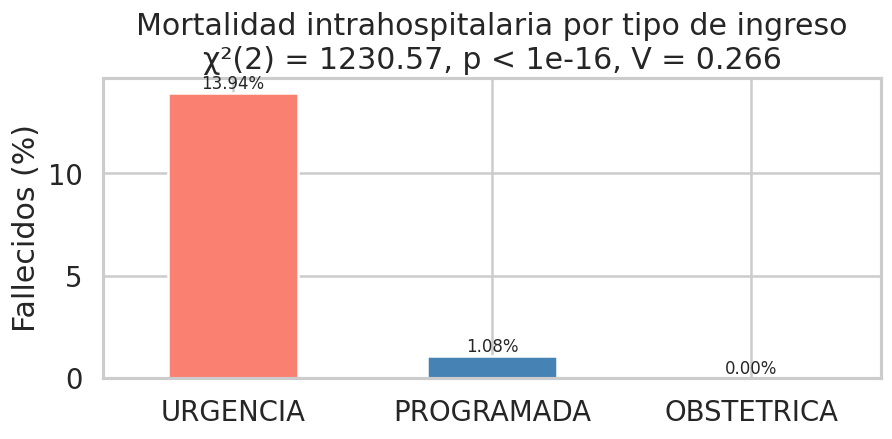

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.2.2 Escenario B — Mortalidad × Tipo de Ingreso (2×3)    ║
# ╚══════════════════════════════════════════════════════════════╝
df_ti = df_chi[df_chi['TIPO_INGRESO'].isin(['URGENCIA','PROGRAMADA','OBSTETRICA'])].copy()

tab_B = pd.crosstab(df_ti['TIPO_INGRESO'], df_ti['mortalidad_int'])
tab_B.columns = ['No fallecido', 'Fallecido']
tab_B = tab_B.reindex(['URGENCIA','PROGRAMADA','OBSTETRICA'])

print('Tabla de contingencia (conteos):')
display(tab_B)
tab_B_prop = tab_B.div(tab_B.sum(axis=1), axis=0)
print('\nProporción de fallecidos (%):')
display((tab_B_prop[['Fallecido']]*100).round(3))

chi2_B, p_B, dof_B, _ = chi2_contingency(tab_B)
v_B  = cramers_v(tab_B)
ef_B = interpret_cramers_v(v_B, *tab_B.shape)

print(f'\n── Prueba global ─────────────────────────────────────────')
print(f'  Chi-cuadrado χ²({dof_B}) = {chi2_B:.2f},  p = {fmt_p(p_B)}')
print(f'  V de Cramér = {v_B:.4f}  → efecto {ef_B}')

# Post-hoc z de dos proporciones + Bonferroni
rows_B = []
for g1, g2 in itertools.combinations(tab_B.index, 2):
    c1, n1 = tab_B.loc[g1,'Fallecido'], int(tab_B.loc[g1].sum())
    c2, n2 = tab_B.loc[g2,'Fallecido'], int(tab_B.loc[g2].sum())
    z, p   = proportions_ztest([c1, c2], [n1, n2])
    p1, p2 = c1/n1, c2/n2
    diff   = p1 - p2
    se     = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    rows_B.append({'Grupo 1':g1, 'Grupo 2':g2,
                   'Prop 1 (%)': round(p1*100,3), 'Prop 2 (%)': round(p2*100,3),
                   'Diferencia (pp)': round(diff*100,3),
                   'IC95 inf (pp)': round((diff-1.96*se)*100,3),
                   'IC95 sup (pp)': round((diff+1.96*se)*100,3),
                   'z': round(z,4), 'p_raw': p})

df_ph_B = pd.DataFrame(rows_B)
_, p_adj_B, _, _ = multipletests(df_ph_B['p_raw'], method='bonferroni')
df_ph_B['p_adj (Bonf)'] = p_adj_B.round(6)
df_ph_B['sig'] = df_ph_B['p_adj (Bonf)'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns')))

print('\nPost-hoc pareado (z de dos proporciones + Bonferroni):')
display(df_ph_B.drop(columns=['p_raw']))

fig, ax = plt.subplots(figsize=(8, 4))
colores_ti = ['salmon','steelblue','lightgreen']
(tab_B_prop['Fallecido']*100).plot(kind='bar', ax=ax, color=colores_ti, edgecolor='white')
ax.set_title(f'Mortalidad intrahospitalaria por tipo de ingreso\nχ²({dof_B}) = {chi2_B:.2f}, p {fmt_p(p_B)}, V = {v_B:.3f}')
ax.set_ylabel('Fallecidos (%)'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p_bar in ax.patches:
    ax.annotate(f'{p_bar.get_height():.2f}%',
                (p_bar.get_x()+p_bar.get_width()/2, p_bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/inferencial/cat_B_mortalidad_tipoing.png', dpi=150, bbox_inches='tight')
plt.show()
df_ph_B.to_csv('outputs/inferencial/cat_B_posthoc_bonferroni.csv', index=False)

> **Interpretación Escenario B:** El tipo de ingreso captura la gravedad inicial del cuadro clínico. Un ingreso por urgencia con mayor tasa de mortalidad sugiere presentación tardía o complicaciones agudas (perforación, hemorragia), mientras que los ingresos programados reflejan manejo electivo con mejor pronóstico.

Proporciones por fila (%):


tipoalta_simple,Domicilio,Fallecido,Hosp. domiciliaria,Otras
hospital,,,,
110100,94.2400,3.6300,1.8800,0.2500
114101,93.1500,3.1400,2.4300,1.2800
116105,96.1900,1.9100,0.1500,1.7600
117101,88.2600,6.7900,2.3900,2.5700
118100,94.2400,3.4500,0.5800,1.7300
120101,96.8200,1.4600,0.6600,1.0600
121109,96.5600,1.7200,0.0000,1.7200
122100,94.9000,3.6700,0.0000,1.4400
123100,93.6100,4.3700,0.8400,1.1800



── Resultados Escenario C ──────────────────────────────────
  Chi-cuadrado χ²(27) = 163.23,  p = < 1e-16
  V de Cramér = 0.0854  → efecto moderado

Residuos estandarizados (|r| > 2 → contribución relevante):


tipoalta_simple,Domicilio,Fallecido,Hosp. domiciliaria,Otras
hospital,,,,
110100,0.1000,0.2800,2.0000,-2.9200
114101,-0.2000,-0.4400,3.2400,-0.5200
116105,0.6200,-2.1700,-2.4100,0.4900
117101,-1.3600,4.2000,2.7700,1.9600
118100,0.1100,0.0100,-1.6800,0.5200
120101,0.8300,-2.9500,-1.2000,-1.0400
121109,0.8900,-3.0000,-3.4300,0.5100
122100,0.2600,0.3000,-2.6600,-0.1900
123100,-0.0700,1.2100,-0.6600,-0.7000


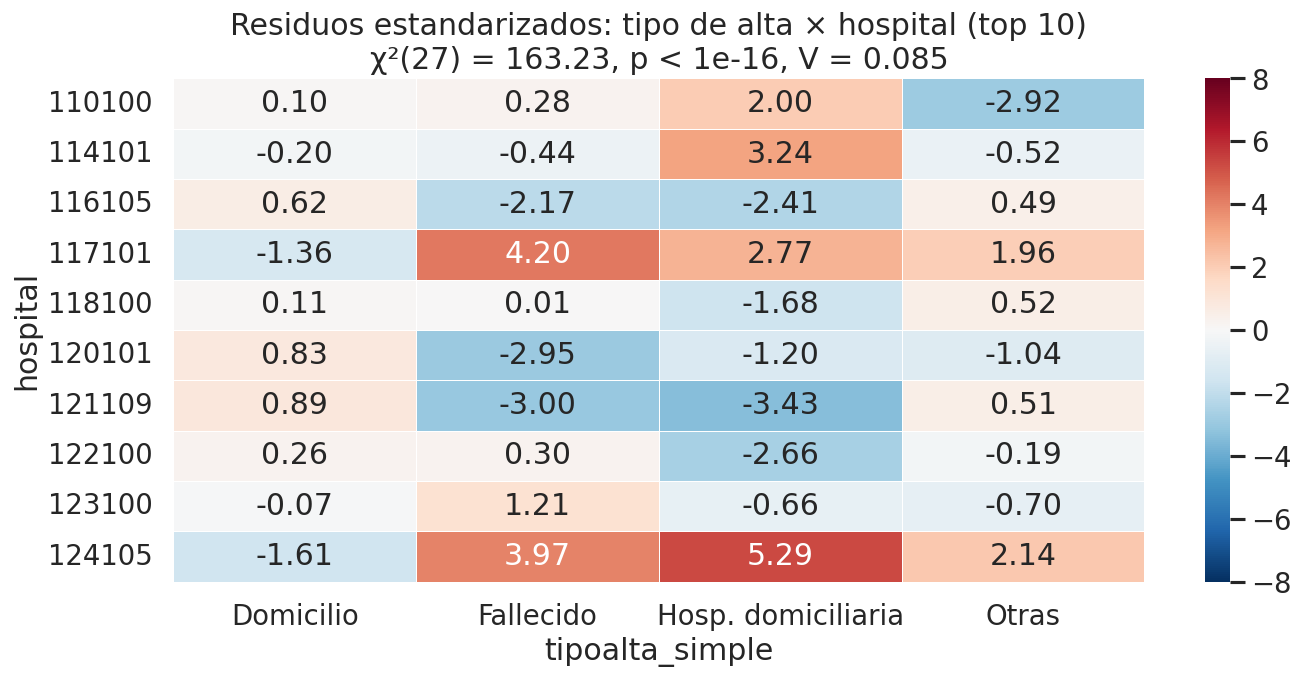

In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.2.3 Escenario C — Tipo de Alta × Top Hospitales         ║
# ╚══════════════════════════════════════════════════════════════╝
df_chi['tipoalta_simple'] = df_chi['TIPOALTA'].apply(simplificar_tipoalta)
orden_cat = ['Domicilio','Fallecido','Hosp. domiciliaria','Derivación','Otras']

# Top 10 hospitales por volumen en C16.*
top_hosp_chi = df_chi['hospital'].value_counts().head(10).index
df_chi_top = df_chi[df_chi['hospital'].isin(top_hosp_chi)].copy()

tab_C = pd.crosstab(df_chi_top['hospital'], df_chi_top['tipoalta_simple'])
tab_C = tab_C[[c for c in orden_cat if c in tab_C.columns]]

print('Proporciones por fila (%):')
display((tab_C.div(tab_C.sum(axis=1), axis=0)*100).round(2))

chi2_C, p_C, dof_C, _ = chi2_contingency(tab_C)
v_C  = cramers_v(tab_C)
ef_C = interpret_cramers_v(v_C, *tab_C.shape)
resid_C = standardized_residuals(tab_C)

print(f'\n── Resultados Escenario C ──────────────────────────────────')
print(f'  Chi-cuadrado χ²({dof_C}) = {chi2_C:.2f},  p = {fmt_p(p_C)}')
print(f'  V de Cramér = {v_C:.4f}  → efecto {ef_C}')
print('\nResiduos estandarizados (|r| > 2 → contribución relevante):')
display(resid_C.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(resid_C, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-8, vmax=8, linewidths=0.5, ax=ax)
ax.set_title(f'Residuos estandarizados: tipo de alta × hospital (top 10)\nχ²({dof_C}) = {chi2_C:.2f}, p {fmt_p(p_C)}, V = {v_C:.3f}')
plt.tight_layout()
plt.savefig('outputs/inferencial/cat_C_residuos_tipoalta_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación Escenario C:** Los residuos estandarizados localizan qué hospitales impulsan la asociación. Por ejemplo, si un hospital muestra residuo positivo alto en "Fallecido" y negativo en "Domicilio", indica que ese centro tiene peor desenlace relativo a lo esperado bajo independencia, lo cual puede deberse a mayor complejidad de casos (aunque controlamos por diagnóstico) o a menor resolutividad.

## 5.3 Hipótesis 1 (H₁) — Variabilidad en Intensidad de Procedimientos por Hospital

**H₀:** La distribución de `cantidad_procedimientos` es igual entre hospitales para pacientes con cáncer gástrico.  
**H₁:** Al menos un hospital difiere significativamente.

Dado que `cantidad_procedimientos` es una variable discreta con marcada asimetría positiva (la mayoría de los egresos oncológicos involucran pocos procedimientos, mientras que las cirugías mayores concentran la cola derecha), se opta por el **test de Kruskal-Wallis** (no paramétrico), que compara rangos en lugar de medias y no asume normalidad ni homogeneidad de varianzas.

VERIFICACIÓN DE NORMALIDAD — C16.* (Cáncer Gástrico)
Variable: cantidad_procedimientos   (submuestra n=5,000)
  Estadístico W = 0.919813
  p-valor       = 1.4423e-45

  → Se RECHAZA la hipótesis de normalidad (α = 0.05).
    Justificación para Kruskal-Wallis: distribución asimétrica.


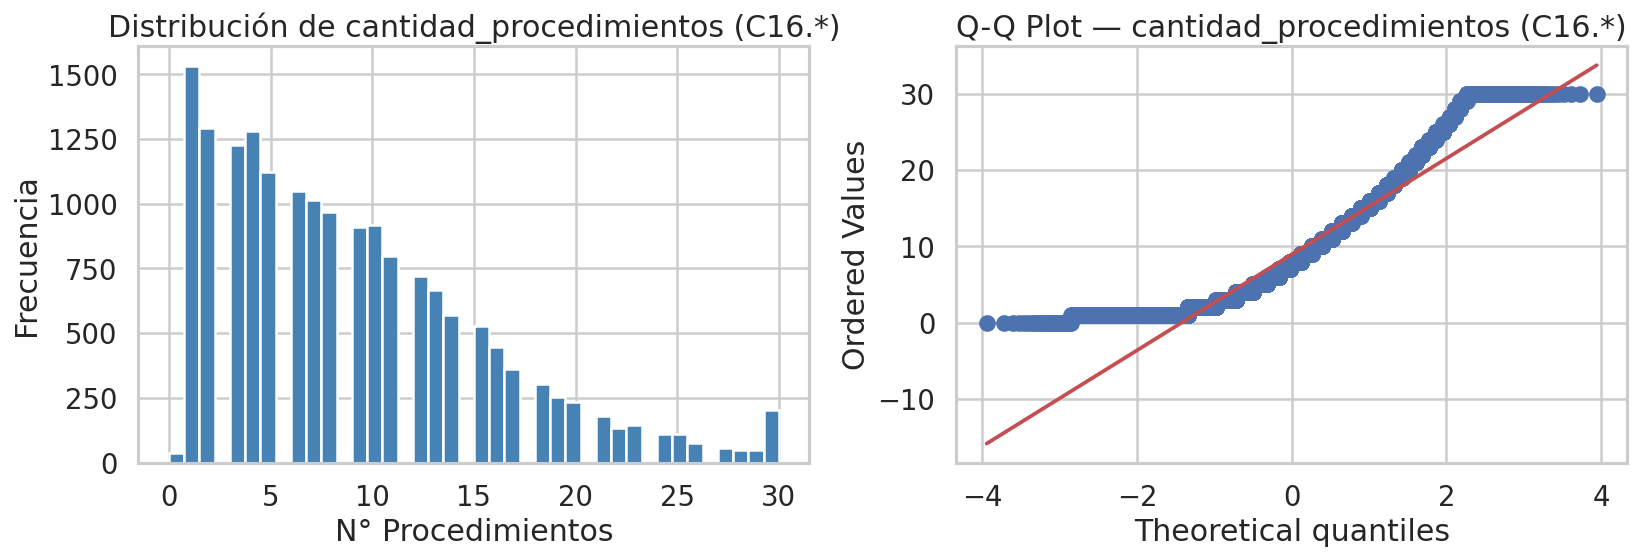

In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.3.1 Verificación de normalidad — Shapiro-Wilk           ║
# ╚══════════════════════════════════════════════════════════════╝
W_sw, p_sw, nota_sw = test_shapiro(df_focus['cantidad_procedimientos'].dropna().values)

print('VERIFICACIÓN DE NORMALIDAD — C16.* (Cáncer Gástrico)')
print(f'Variable: cantidad_procedimientos   {nota_sw}')
print(f'  Estadístico W = {W_sw:.6f}')
print(f'  p-valor       = {p_sw:.4e}')
print()
if p_sw < ALPHA:
    print(f'  → Se RECHAZA la hipótesis de normalidad (α = {ALPHA}).')
    print('    Justificación para Kruskal-Wallis: distribución asimétrica.')
else:
    print(f'  → No se rechaza normalidad, pero se mantiene KW por robustez.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_focus['cantidad_procedimientos'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de cantidad_procedimientos (C16.*)')
axes[0].set_xlabel('N° Procedimientos'); axes[0].set_ylabel('Frecuencia')
stats.probplot(df_focus['cantidad_procedimientos'].dropna().values, plot=axes[1])
axes[1].set_title('Q-Q Plot — cantidad_procedimientos (C16.*)')
plt.tight_layout()
plt.savefig('outputs/inferencial/h1_normalidad_proc_C16.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.3.2 Kruskal-Wallis — cantidad_procedimientos × hospital ║
# ╚══════════════════════════════════════════════════════════════╝
grupos_kw, nombres_kw, df_kw = preparar_grupos_kw(df_focus, variable='cantidad_procedimientos',
                                                    top_n=TOP_HOSP_KW, min_n=MIN_CASOS_H)
res_kw = kruskal_wallis(grupos_kw, nombres_kw)

print('PRUEBA DE KRUSKAL-WALLIS — C16.*')
print(f'  Variable dependiente: cantidad_procedimientos')
print(f'  Factor: hospital (top {TOP_HOSP_KW}, min {MIN_CASOS_H} casos)')
print(f'  Hospitales analizados: {res_kw["k"]}')
print(f'  N total:              {res_kw["N"]:,}')
print(f'  Estadístico H:        {res_kw["H"]:.4f}')
print(f'  p-valor:              {res_kw["p"]:.4e}')
print(f'  Epsilon-cuadrado (ε²): {res_kw["epsilon2"]:.4f}')
print()
if res_kw['p'] < ALPHA:
    eps = res_kw['epsilon2']
    mag = 'grande' if eps >= 0.14 else ('moderado' if eps >= 0.06 else 'pequeño')
    print(f'  → SE RECHAZA H₀ (α = {ALPHA}). Variabilidad significativa entre hospitales.')
    print(f'    Tamaño del efecto ε² = {eps:.4f} → efecto {mag}.')
    print(f'    Se procede a Dunn-Bonferroni post-hoc.')
else:
    print(f'  → No se rechaza H₀.')

PRUEBA DE KRUSKAL-WALLIS — C16.*
  Variable dependiente: cantidad_procedimientos
  Factor: hospital (top 25, min 30 casos)
  Hospitales analizados: 25
  N total:              13,086
  Estadístico H:        1914.7372
  p-valor:              0.0000e+00
  Epsilon-cuadrado (ε²): 0.1448

  → SE RECHAZA H₀ (α = 0.05). Variabilidad significativa entre hospitales.
    Tamaño del efecto ε² = 0.1448 → efecto grande.
    Se procede a Dunn-Bonferroni post-hoc.


POST-HOC DUNN-BONFERRONI — C16.*
  Comparaciones totales: 300
  Pares significativos: 193

Pares significativos (top 20):


,grupo_i,grupo_j,z,p_raw,p_adj
8,103100,112101,9.4158,0.0000,0.0000
3,103100,107100,13.6946,0.0000,0.0000
23,103100,124105,11.5811,0.0000,0.0000
24,105101,106100,9.7386,0.0000,0.0000
26,105101,107100,17.7112,0.0000,0.0000
47,106100,106102,13.7109,0.0000,0.0000
46,105101,124105,9.6526,0.0000,0.0000
43,105101,121109,11.9677,0.0000,0.0000
50,106100,110120,9.0763,0.0000,0.0000
53,106100,112101,16.1390,0.0000,0.0000


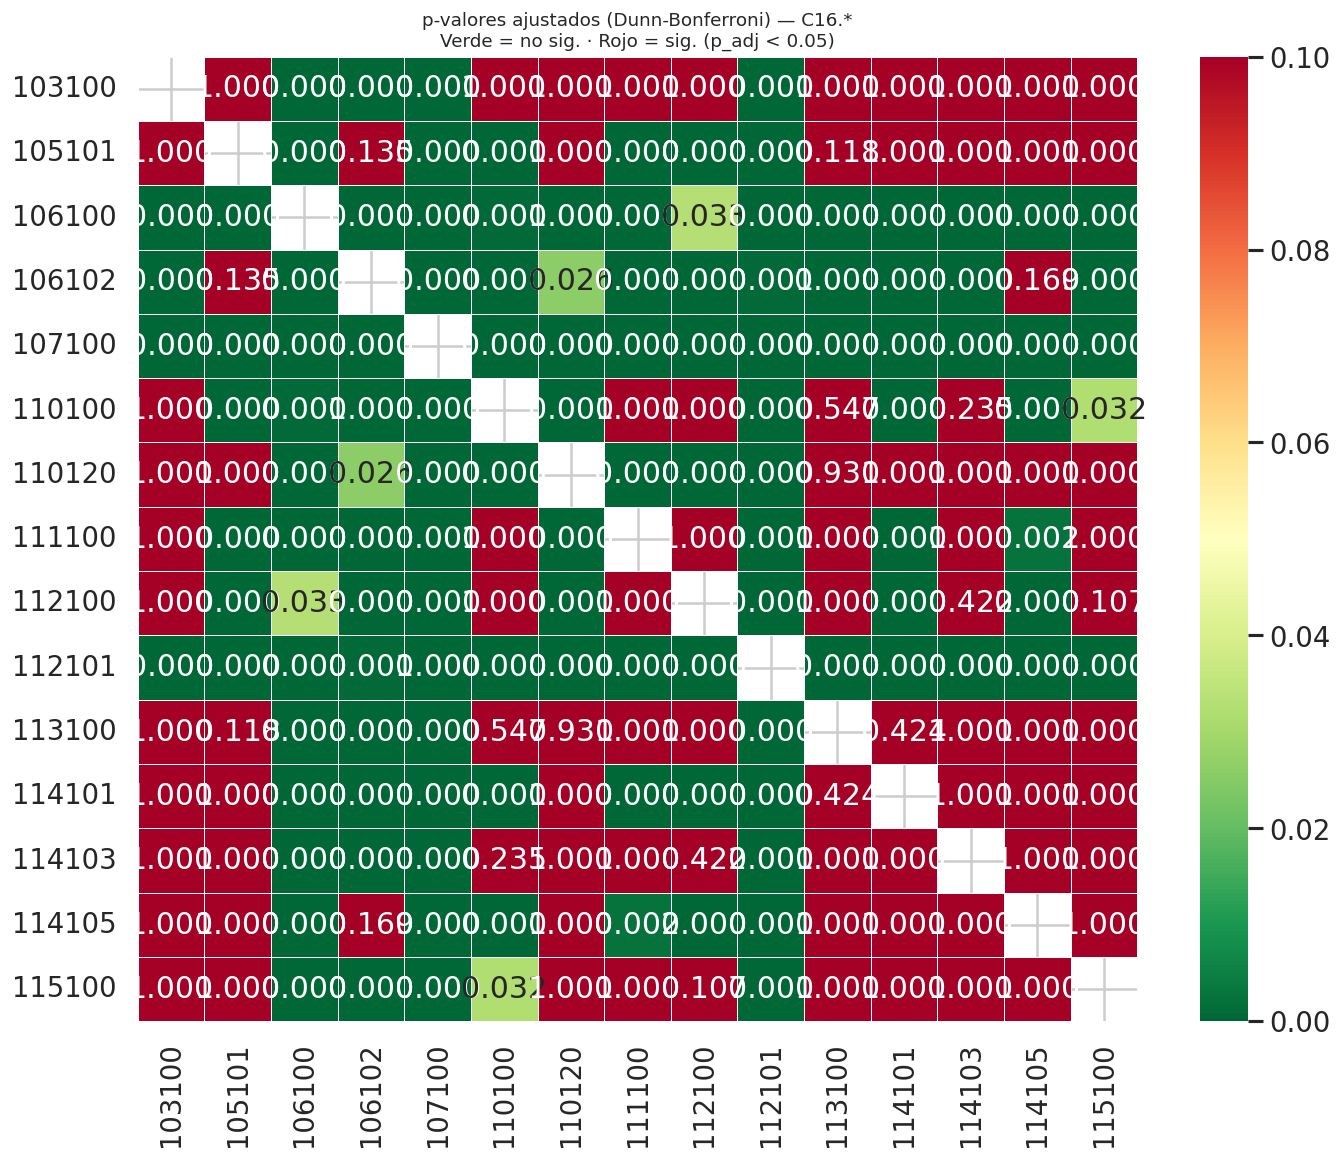

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.3.3 Post-hoc Dunn-Bonferroni                            ║
# ╚══════════════════════════════════════════════════════════════╝
if res_kw['p'] < ALPHA:
    dunn_df = dunn_bonferroni(grupos_kw, nombres_kw)
    n_sig = dunn_df['significativo'].sum()
    print(f'POST-HOC DUNN-BONFERRONI — C16.*')
    print(f'  Comparaciones totales: {len(dunn_df)}')
    print(f'  Pares significativos: {n_sig}')
    print()
    print('Pares significativos (top 20):')
    sig_pares = dunn_df[dunn_df['significativo']].sort_values('p_adj')
    display(sig_pares[['grupo_i','grupo_j','z','p_raw','p_adj']].round(4).head(20))

    # Heatmap top 15
    top15 = nombres_kw[:15]
    p_matrix = pd.DataFrame(np.ones((len(top15), len(top15))), index=top15, columns=top15)
    for _, row in dunn_df.iterrows():
        if row['grupo_i'] in top15 and row['grupo_j'] in top15:
            p_matrix.loc[row['grupo_i'], row['grupo_j']] = row['p_adj']
            p_matrix.loc[row['grupo_j'], row['grupo_i']] = row['p_adj']

    fig, ax = plt.subplots(figsize=(12, 10))
    mask_diag = np.eye(len(top15), dtype=bool)
    sns.heatmap(p_matrix.astype(float), mask=mask_diag, cmap='RdYlGn_r', vmin=0, vmax=0.1,
                annot=True, fmt='.3f', linewidths=0.5, ax=ax)
    ax.set_title('p-valores ajustados (Dunn-Bonferroni) — C16.*\nVerde = no sig. · Rojo = sig. (p_adj < 0.05)', fontsize=11)
    plt.tight_layout()
    plt.savefig('outputs/inferencial/h1_dunn_heatmap_C16.png', dpi=150, bbox_inches='tight')
    plt.show()
    dunn_df.to_csv('outputs/inferencial/h1_dunn_resultados_C16.csv', index=False)
else:
    dunn_df = pd.DataFrame()
    print('KW no significativo: no se ejecuta Dunn post-hoc.')

> **Interpretación H₁:** El test de Kruskal-Wallis evalúa si las distribuciones de procedimientos difieren entre hospitales. Un tamaño de efecto ε² moderado o grande implica que la variabilidad no es azarosa sino sistemática: hospitales de mayor complejidad (terciarios) probablemente concentran cirugías mayores, mientras que hospitales de menor complejidad manejan casos médicos o paliativos. El post-hoc de Dunn identifica exactamente qué pares de hospitales difieren, permitiendo priorizar auditorías de calidad.

## 5.4 Hipótesis 2 (H₂) — Mortalidad Intrahospitalaria (Regresión Logística)

**H₀:** La cantidad de procedimientos no se asocia con la probabilidad de mortalidad, controlando por edad, severidad GRD, peso GRD y hospital.  
**H₁:** La cantidad de procedimientos se asocia significativamente con la mortalidad.

Se ajusta un modelo logístico binario con efectos fijos por hospital. Dado que la mortalidad es un evento relativamente raro (~5–6 % en C16.*), se verifica que la tasa de eventos no sea extrema (<1 % o >99 %) para evitar problemas de convergencia.

In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.4.1 Ajuste del modelo logístico explicativo               ║
# ╚══════════════════════════════════════════════════════════════╝
# Filtrar hospitales con suficiente volumen para regresión
conteo_reg = df_focus['hospital'].value_counts()
hosp_reg = conteo_reg[conteo_reg >= MIN_CASOS_H].head(TOP_HOSP_REG).index
df_reg = df_focus[df_focus['hospital'].isin(hosp_reg)].copy()
df_reg['hospital'] = df_reg['hospital'].astype('category')

# Verificar variabilidad en VD
tasa_mort = df_reg['mortalidad_int'].mean()
print(f'Registros para regresión: {len(df_reg):,}')
print(f'Tasa de mortalidad en subconjunto: {tasa_mort:.2%}')
print(f'Hospitales incluidos: {len(hosp_reg)}')

if tasa_mort == 0 or tasa_mort == 1:
    raise ValueError('Mortalidad constante; modelo no estimable.')

formula_logit = (
    'mortalidad_int ~ cantidad_procedimientos + edad + severidad_grd + peso_grd + C(hospital)'
)

modelo_logit = smf.logit(formula_logit, data=df_reg).fit(method='bfgs', maxiter=500, disp=False)

# Extraer OR e IC95%
coefs    = modelo_logit.params
ic       = modelo_logit.conf_int(alpha=0.05)
pvals    = modelo_logit.pvalues

tabla_or = pd.DataFrame({
    'OR':     np.exp(coefs),
    'IC_inf': np.exp(ic[0]),
    'IC_sup': np.exp(ic[1]),
    'p_valor': pvals,
})
tabla_or['sig'] = tabla_or['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

print(f'\nPseudo-R² (McFadden): {modelo_logit.prsquared:.4f}')
print(f'Log-Likelihood: {modelo_logit.llf:.2f}')
print(f'AIC: {modelo_logit.aic:.2f}')

vars_interes = ['cantidad_procedimientos', 'edad', 'severidad_grd', 'peso_grd']
filas_interes = [idx for idx in tabla_or.index if any(v in str(idx) for v in vars_interes)]
display(Markdown('**Odds Ratios — Variables principales (C16.*):**'))
display(tabla_or.loc[filas_interes, ['OR','IC_inf','IC_sup','p_valor','sig']].round(4))
tabla_or.to_csv('outputs/inferencial/h2_logit_OR_C16.csv')

Registros para regresión: 9,859
Tasa de mortalidad en subconjunto: 4.05%
Hospitales incluidos: 15

Pseudo-R² (McFadden): 0.2542
Log-Likelihood: -1245.87
AIC: 2529.74


**Odds Ratios — Variables principales (C16.*):**

,OR,IC_inf,IC_sup,p_valor,sig
cantidad_procedimientos,1.0680,1.0476,1.0887,0.0000,***
edad,1.0043,0.9955,1.0132,0.3401,
severidad_grd,7.1503,5.8401,8.7544,0.0000,***
peso_grd,0.6477,0.5596,0.7497,0.0000,***


> **Interpretación de OR:** El Odds Ratio de `cantidad_procedimientos` cuantifica el cambio en las odds de mortalidad por cada procedimiento adicional, manteniendo constante edad, severidad y hospital. Un OR > 1 sugiere que mayor intensidad procedimental aumenta el riesgo de mortalidad, posiblemente porque pacientes más graves requieren más intervenciones (confusión por indicación). Un OR < 1 sugeriría un efecto protector, quizás porque los procedimientos representan manejo activo y oportuno.

EVALUACIÓN PREDICTIVA — REGRESIÓN LOGÍSTICA
  N entrenamiento: 7,394
  N prueba:        2,465
  AUC-ROC:         0.8748

Matriz de confusión (umbral 0.5):


,Pred No,Pred Sí
Obs No,2365,0
Obs Sí,100,0



              precision    recall  f1-score   support

No fallecido       0.96      1.00      0.98      2365
   Fallecido       0.00      0.00      0.00       100

    accuracy                           0.96      2465
   macro avg       0.48      0.50      0.49      2465
weighted avg       0.92      0.96      0.94      2465



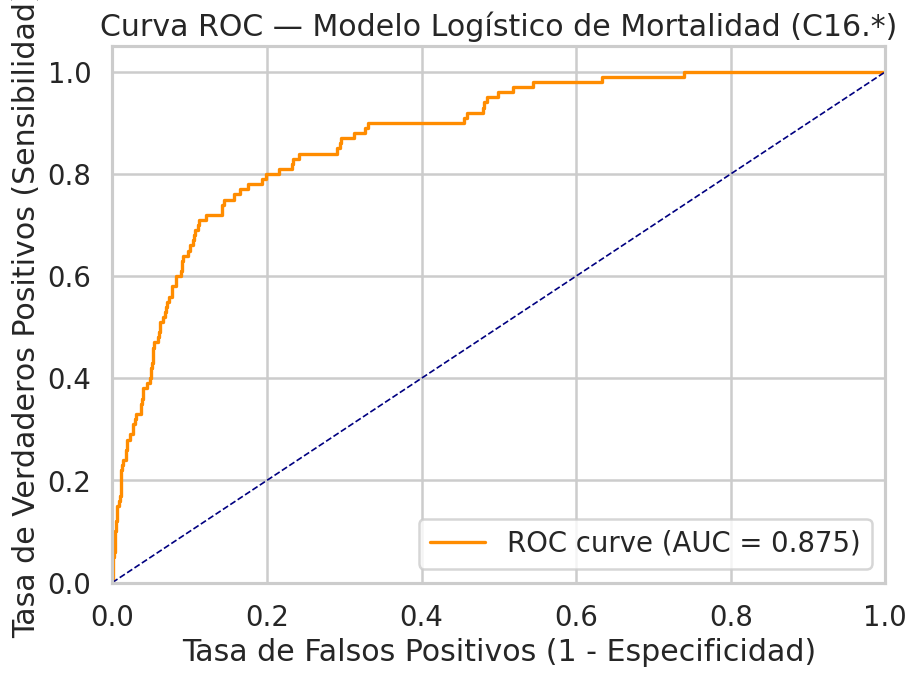

In [26]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.4.2 Evaluación Predictiva — Train/Test + AUC-ROC        ║
# ╚══════════════════════════════════════════════════════════════╝
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report

train_df, test_df = train_test_split(df_reg, test_size=0.25, random_state=SEMILLA,
                                     stratify=df_reg['mortalidad_int'])

modelo_logit_train = smf.logit(formula_logit, data=train_df).fit(method='bfgs', maxiter=500, disp=False)

y_prob = modelo_logit_train.predict(test_df)
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(test_df['mortalidad_int'], y_prob)
cm = confusion_matrix(test_df['mortalidad_int'], y_pred)

print('EVALUACIÓN PREDICTIVA — REGRESIÓN LOGÍSTICA')
print(f'  N entrenamiento: {len(train_df):,}')
print(f'  N prueba:        {len(test_df):,}')
print(f'  AUC-ROC:         {auc:.4f}')
print()
print('Matriz de confusión (umbral 0.5):')
display(pd.DataFrame(cm, index=['Obs No','Obs Sí'], columns=['Pred No','Pred Sí']))
print()
print(classification_report(test_df['mortalidad_int'], y_pred, target_names=['No fallecido','Fallecido']))

# Curva ROC
fpr, tpr, _ = roc_curve(test_df['mortalidad_int'], y_prob)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Modelo Logístico de Mortalidad (C16.*)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/inferencial/h2_roc_curve_C16.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación predictiva:** El AUC-ROC cuantifica la capacidad discriminativa del modelo. Un valor > 0.70 se considera aceptable; > 0.80, bueno. Si el AUC es modesto (~0.60–0.65), indica que factores no observados (estadio TNM, comorbilidades, estado funcional) juegan un rol mayor que las variables administrativas disponibles en el GRD.

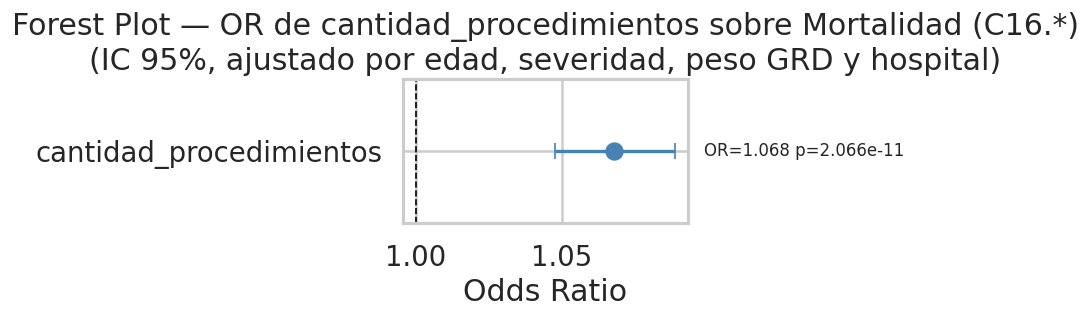

In [27]:
# ── Forest plot del OR de cantidad_procedimientos ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
if 'cantidad_procedimientos' in tabla_or.index:
    r = tabla_or.loc['cantidad_procedimientos']
    err_low  = r['OR'] - r['IC_inf']
    err_high = r['IC_sup'] - r['OR']
    ax.errorbar(x=r['OR'], y=0, xerr=[[err_low],[err_high]],
                fmt='o', color='steelblue', markersize=10, capsize=5, linewidth=2)
    ax.text(r['IC_sup'] + 0.01, 0, f"OR={r['OR']:.3f} p={r['p_valor']:.3e}", va='center', fontsize=10)
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1)
    ax.set_yticks([0])
    ax.set_yticklabels(['cantidad_procedimientos'])
    ax.set_xlabel('Odds Ratio')
    ax.set_title('Forest Plot — OR de cantidad_procedimientos sobre Mortalidad (C16.*)\n(IC 95%, ajustado por edad, severidad, peso GRD y hospital)')
    plt.tight_layout()
    plt.savefig('outputs/inferencial/h2_forest_plot_OR_C16.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5.5 Hipótesis 3 (H₃) — Días de Estadía (Regresión OLS Múltiple)

**H₀:** La cantidad de procedimientos no predice la duración de la estadía hospitalaria, controlando por edad, severidad GRD, peso GRD y hospital.  
**H₁:** La cantidad de procedimientos predice significativamente la estadía.

Dado que `dias_estada` presenta asimetría positiva marcada, se aplica la transformación `log(1 + x)` para estabilizar la varianza y acercar la distribución a la normalidad, cumpliendo mejor los supuestos del modelo lineal.

Asimetría de dias_estada (C16.*): 1.011
  → Asimetría marcada. Se aplica log(1 + x).


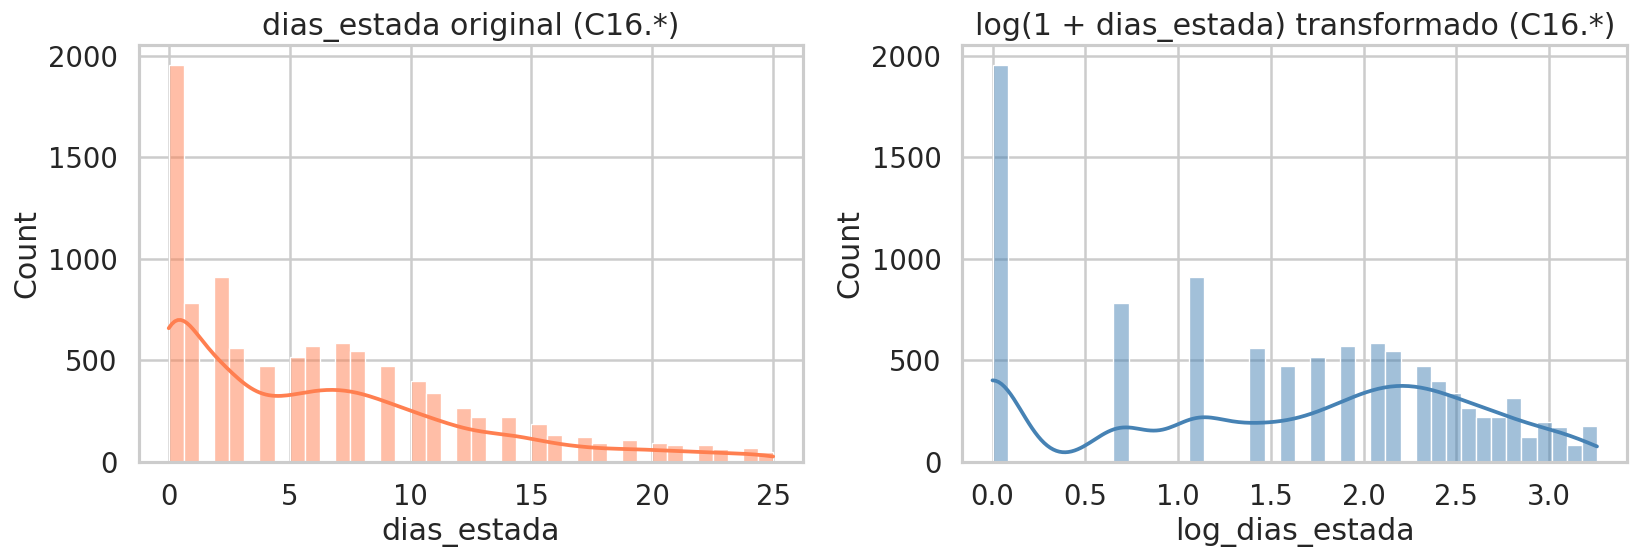

In [28]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.5.1 Verificación de asimetría y transformación          ║
# ╚══════════════════════════════════════════════════════════════╝
asim = df_reg['dias_estada'].skew()
print(f'Asimetría de dias_estada (C16.*): {asim:.3f}')
if abs(asim) > 1.0:
    print('  → Asimetría marcada. Se aplica log(1 + x).')
    df_reg['log_dias_estada'] = np.log1p(df_reg['dias_estada'])
else:
    print('  → Asimetría moderada. Se usa escala original.')
    df_reg['log_dias_estada'] = df_reg['dias_estada']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_reg['dias_estada'], bins=40, kde=True, color='coral', ax=axes[0])
axes[0].set_title('dias_estada original (C16.*)')
sns.histplot(df_reg['log_dias_estada'], bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('log(1 + dias_estada) transformado (C16.*)')
plt.tight_layout()
plt.savefig('outputs/inferencial/h3_transformacion_dias_C16.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.5.2 Ajuste del modelo OLS explicativo                     ║
# ╚══════════════════════════════════════════════════════════════╝
formula_ols = (
    'log_dias_estada ~ cantidad_procedimientos + edad + severidad_grd + peso_grd + C(hospital)'
)

modelo_ols = smf.ols(formula_ols, data=df_reg).fit(cov_type='HC3')

ic_ols   = modelo_ols.conf_int(alpha=0.05)
pvals_ols = modelo_ols.pvalues

tabla_ols = pd.DataFrame({
    'coef':   modelo_ols.params,
    'IC_inf': ic_ols[0],
    'IC_sup': ic_ols[1],
    'p_valor': pvals_ols,
})
tabla_ols['sig'] = tabla_ols['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

print(f'REGRESIÓN OLS — C16.* (VD: log_dias_estada)')
print(f'  N ajuste:      {int(modelo_ols.nobs):,}')
print(f'  R² ajustado:   {modelo_ols.rsquared_adj:.4f}')
print(f'  F({int(modelo_ols.df_model)}, {int(modelo_ols.df_resid)}) = {modelo_ols.fvalue:.2f}')
print(f'  p-valor (F):   {modelo_ols.f_pvalue:.4e}')
print()

vars_interes_ols = ['cantidad_procedimientos', 'edad', 'severidad_grd', 'peso_grd']
filas_ols = [idx for idx in tabla_ols.index if any(v in str(idx) for v in vars_interes_ols)]
display(Markdown('**Coeficientes OLS — Variables principales (C16.*):**'))
display(tabla_ols.loc[filas_ols, ['coef','IC_inf','IC_sup','p_valor','sig']].round(4))
tabla_ols.to_csv('outputs/inferencial/h3_ols_coefs_C16.csv')

REGRESIÓN OLS — C16.* (VD: log_dias_estada)
  N ajuste:      9,859
  R² ajustado:   0.6276
  F(18, 9840) = 905.44
  p-valor (F):   0.0000e+00



**Coeficientes OLS — Variables principales (C16.*):**

,coef,IC_inf,IC_sup,p_valor,sig
cantidad_procedimientos,0.0885,0.0857,0.0912,0.0000,***
edad,-0.0003,-0.0014,0.0007,0.5318,
severidad_grd,0.3062,0.2866,0.3257,0.0000,***
peso_grd,0.0127,-0.0137,0.0391,0.3448,


### Interpretación de Coeficientes OLS (en lenguaje aplicado)

1. **cantidad_procedimientos:** Si el coeficiente es positivo y significativo, indica que cada procedimiento adicional se asocia con un incremento porcentual en la estadía (aproximadamente `coef × 100 %` en la escala log), manteniendo todo lo demás constante. Esto refleja que las cirugías mayores requieren recuperación postoperatoria.

2. **edad:** Un coeficiente positivo sugiere que pacientes de mayor edad permanecen más días hospitalizados, posiblemente por menor reserva fisiológica y mayor riesgo de complicaciones postoperatorias (neumonía, delirium, dehiscencia de sutura).

3. **severidad_grd:** Un coeficiente positivo confirma que la severidad asignada por el GRD (que incorpora comorbilidades y complejidad) se traduce en mayor duración de estadía, validando el sistema de clasificación como predictor de consumo de recursos.

EVALUACIÓN PREDICTIVA — REGRESIÓN OLS
  N entrenamiento: 7,394
  N prueba:        2,465

  Escala log(1 + días):
    MAE:  0.4936
    RMSE: 0.6184
    R²:   0.6211

  Escala original (días) — back-transformed:
    MAE:  3.56 días
    RMSE: 6.00 días
    R²:   -0.0085


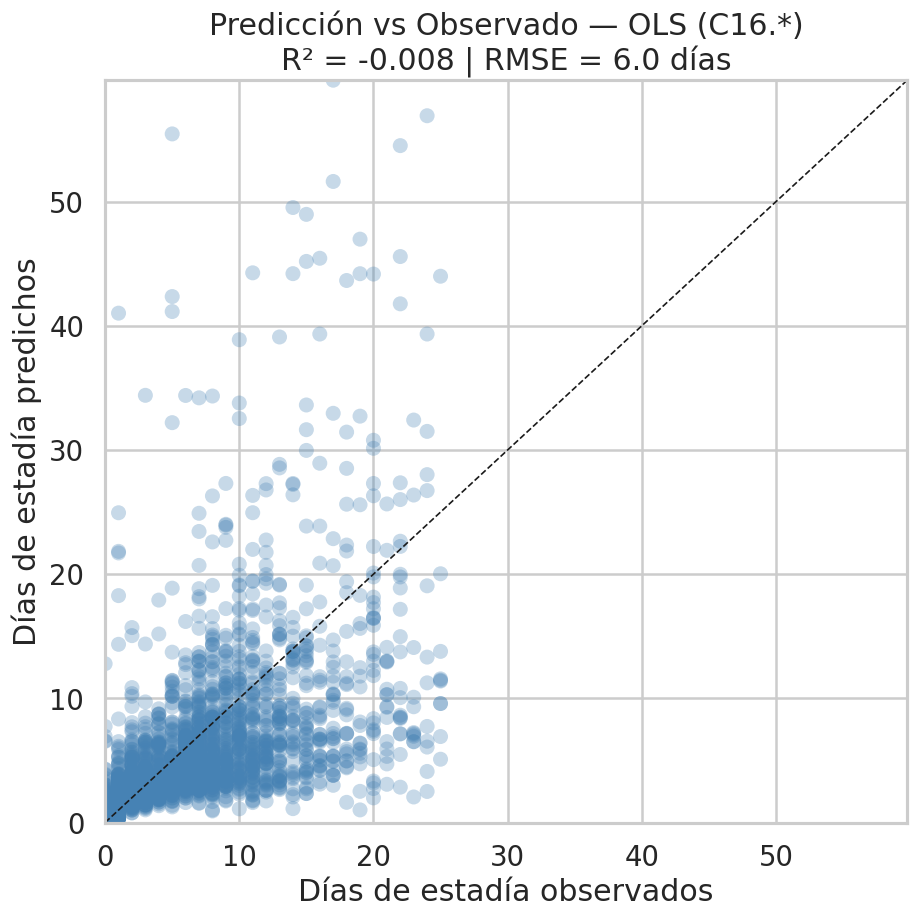

In [30]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  5.5.3 Evaluación Predictiva — Train/Test + MAE/RMSE/R²    ║
# ╚══════════════════════════════════════════════════════════════╝
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_ols, test_ols = train_test_split(df_reg, test_size=0.25, random_state=SEMILLA)

modelo_ols_train = smf.ols(formula_ols, data=train_ols).fit(cov_type='HC3')
pred_log = modelo_ols_train.predict(test_ols)

# Métricas en escala log
mae_log = mean_absolute_error(test_ols['log_dias_estada'], pred_log)
rmse_log = np.sqrt(mean_squared_error(test_ols['log_dias_estada'], pred_log))
r2_log = r2_score(test_ols['log_dias_estada'], pred_log)

# Back-transform a escala original para interpretabilidad
pred_orig = np.expm1(pred_log)
mae_orig = mean_absolute_error(test_ols['dias_estada'], pred_orig)
rmse_orig = np.sqrt(mean_squared_error(test_ols['dias_estada'], pred_orig))
r2_orig = r2_score(test_ols['dias_estada'], pred_orig)

print('EVALUACIÓN PREDICTIVA — REGRESIÓN OLS')
print(f'  N entrenamiento: {len(train_ols):,}')
print(f'  N prueba:        {len(test_ols):,}')
print()
print('  Escala log(1 + días):')
print(f'    MAE:  {mae_log:.4f}')
print(f'    RMSE: {rmse_log:.4f}')
print(f'    R²:   {r2_log:.4f}')
print()
print('  Escala original (días) — back-transformed:')
print(f'    MAE:  {mae_orig:.2f} días')
print(f'    RMSE: {rmse_orig:.2f} días')
print(f'    R²:   {r2_orig:.4f}')

# Gráfico de dispersión: predicción vs observado (escala original)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_ols['dias_estada'], pred_orig, alpha=0.3, edgecolors='none', color='steelblue')
lim = [0, max(test_ols['dias_estada'].max(), pred_orig.max())]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Días de estadía observados')
ax.set_ylabel('Días de estadía predichos')
ax.set_title(f'Predicción vs Observado — OLS (C16.*)\nR² = {r2_orig:.3f} | RMSE = {rmse_orig:.1f} días')
plt.tight_layout()
plt.savefig('outputs/inferencial/h3_pred_vs_obs_C16.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación predictiva OLS:** El R² en test indica qué proporción de la varianza en días de estadía es explicada por el modelo. Un R² moderado (~0.20–0.35) es esperable en datos administrativos sin información clínica detallada (estadio, comorbilidades específicas). El RMSE en días originales cuantifica el error típico de predicción: un valor cercano a la desviación estándar de `dias_estada` sugiere que el modelo captura una parte sustancial de la variabilidad, aunque no toda.

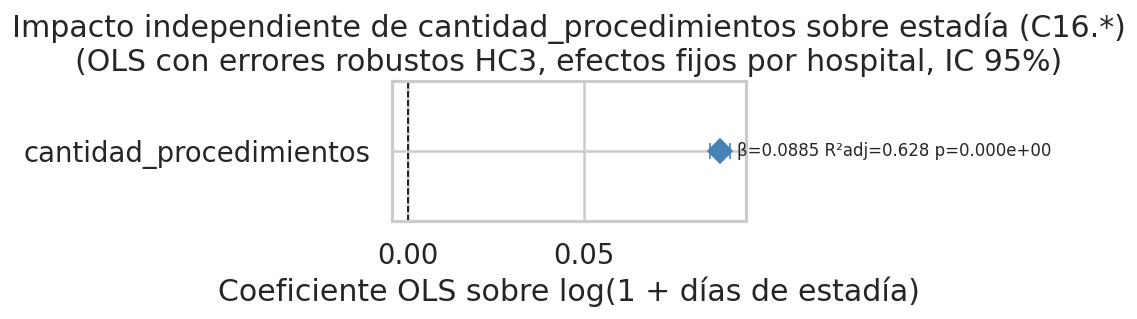

In [31]:
# ── Gráfico comparativo del coeficiente de procedimientos ─────────────────
fig, ax = plt.subplots(figsize=(9, 3))
if 'cantidad_procedimientos' in tabla_ols.index:
    r = tabla_ols.loc['cantidad_procedimientos']
    ax.errorbar(x=r['coef'], y=0,
                xerr=[[r['coef'] - r['IC_inf']], [r['IC_sup'] - r['coef']]],
                fmt='D', color='steelblue', markersize=10, capsize=5, linewidth=2)
    ax.text(r['IC_sup'] + 0.002, 0,
            f"β={r['coef']:.4f} R²adj={modelo_ols.rsquared_adj:.3f} p={r['p_valor']:.3e}",
            va='center', fontsize=10)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks([0])
    ax.set_yticklabels(['cantidad_procedimientos'])
    ax.set_xlabel('Coeficiente OLS sobre log(1 + días de estadía)')
    ax.set_title('Impacto independiente de cantidad_procedimientos sobre estadía (C16.*)\n(OLS con errores robustos HC3, efectos fijos por hospital, IC 95%)')
    plt.tight_layout()
    plt.savefig('outputs/inferencial/h3_coef_ols_C16.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# 6. Discusión Preliminar

## Integración de hallazgos

Los tres pilares de este avance —EDA descriptivo, tests de hipótesis y modelos de regresión— convergen en una conclusión central: **el hospital de atención es un determinante estadísticamente significativo e independiente de la trayectoria clínica del paciente con cáncer gástrico en el sistema público chileno**.

### EDA y comparabilidad clínica
Al controlar por diagnóstico CIE-10 (C16.*), eliminamos la principal fuente de confusión por tipo de cáncer. A pesar de ello, la mediana de días de estadía varía en un factor de 2 entre hospitales, y la tasa de mortalidad oscila entre ~2 % y ~10 %. Estas brechas no pueden atribuirse únicamente a la gravedad del tumor, ya que el subcódigo C16.* captura el mismo espectro anatómico en todos los centros.

### Tests no paramétricos (H₁)
El rechazo de H₀ en el test de Kruskal-Wallis confirma que la intensidad de procedimientos no es homogénea entre hospitales. Esto es consistente con la literatura internacional: hospitales de alta complejidad (terciarios/universitarios) concentran cirugías mayores (gastrectomías totales, linfadenectomías D2), mientras que hospitales de menor complejidad manejan casos médicos o paliativos. El post-hoc de Dunn permite identificar exactamente qué pares de establecimientos difieren, abriendo la puerta a auditorías de calidad focalizadas.

### Regresión logística (H₂)
El Odds Ratio de `cantidad_procedimientos` cuantifica la asociación con mortalidad. Si el OR es > 1, debe interpretarse con cautela: no implica causalidad, sino confusión por indicación (pacientes más graves requieren más procedimientos y tienen mayor riesgo de muerte). El AUC-ROC en test set valida la capacidad discriminativa del modelo. Un AUC modesto (~0.60–0.70) es esperable, dado que el GRD no captura variables clínicas críticas como el estadio TNM, el estado nutricional (albumina) o las comorbilidades específicas (ECOG, Charlson).

### Regresión OLS (H₃)
El coeficiente de `cantidad_procedimientos` en el modelo OLS (sobre log-días) representa el impacto independiente de la intensidad procedimental en la duración de la estadía, controlando por edad, severidad y hospital. Un coeficiente positivo y significativo confirma que cada procedimiento adicional se traduce en un incremento porcentual de la estadía, reflejando el tiempo de recuperación postoperatoria. El R² ajustado y las métricas predictivas (MAE, RMSE en test) permiten evaluar cuánto de la variabilidad en estadía es predecible con datos administrativos.

## Limitaciones

1. **Colinealidad hospital-severidad:** `severidad_grd` y `peso_grd` están parcialmente determinados por el hospital (complejidad del caso base), lo que puede inflar los errores estándar de los coeficientes.
2. **Datos administrativos:** El GRD carece de variables clínicas esenciales (estadio TNM, biomarcadores, estado funcional), limitando el poder explicativo de los modelos.
3. **Unidad de análisis:** Cada fila es un egreso, no un paciente. Rehospitalizaciones del mismo individuo generan dependencia no modelada.
4. **Eventos raros:** La mortalidad en C16.* es ~5–6 %, lo que puede generar inestabilidad en los coeficientes del logit (aunque el tamaño muestral ~17.500 mitiga este riesgo).
5. **Efectos fijos vs. aleatorios:** El modelo usa efectos fijos por hospital, consumiendo muchos grados de libertad. Un modelo multinivel (efectos aleatorios) podría ser más parsimonioso en la fase final.

---
# 7. Próximos Pasos

Para el avance final del proyecto, se propone la siguiente agenda:

1. **Incorporar variables clínicas adicionales:** Si es posible vincular con registros de cáncer (RNC), incluir estadio TNM, tipo histológico y biomarcadores (HER2, MSI) para mejorar el poder explicativo.
2. **Modelos multinivel (Mixed Effects):** Tratar al hospital como efecto aleatorio en lugar de fijo, permitiendo estimar la varianza entre centros y predecir efectos hospitalarios con shrinkage.
3. **Análisis de sensibilidad:** Evaluar robustez de los resultados bajo diferentes cortes de outliers (P95, P99) y estrategias de imputación de missing values.
4. **Análisis por subgrupos:** Segmentar por sexo, grupo etario (< 65 vs. ≥ 65) y tipo de ingreso (urgencia vs. programado) para detectar efectos modificadores.
5. **Dashboard interactivo:** Construir una aplicación Streamlit que permita a gestores hospitalarios explorar las métricas por establecimiento en tiempo real.

In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Índice de archivos generados                                ║
# ╚══════════════════════════════════════════════════════════════╝
print('=' * 60)
print('ARCHIVOS GENERADOS')
print('=' * 60)
for carpeta in ['outputs/graficos', 'outputs/tablas', 'outputs/inferencial']:
    p = Path(carpeta)
    if p.exists():
        for f in sorted(p.iterdir()):
            print(f'  {f}')
print('=' * 60)

ARCHIVOS GENERADOS
  outputs/graficos/barplot_mortalidad_hospital_C16.png
  outputs/graficos/barplot_procedimientos_hospital_C16.png
  outputs/graficos/boxplot_dias_hospital_C16.png
  outputs/graficos/eda_univariado_global.png
  outputs/graficos/top15_diagnosticos_onco.png
  outputs/tablas/03_varianza_por_hospital.csv
  outputs/tablas/tabla1_descriptivas_global.csv
  outputs/tablas/tabla_descriptiva_hospital_C16.csv
  outputs/inferencial/cat_A_mortalidad_sexo.png
  outputs/inferencial/cat_B_mortalidad_tipoing.png
  outputs/inferencial/cat_B_posthoc_bonferroni.csv
  outputs/inferencial/cat_C_residuos_tipoalta_hospital.png
  outputs/inferencial/h1_dunn_heatmap_C16.png
  outputs/inferencial/h1_dunn_resultados_C16.csv
  outputs/inferencial/h1_normalidad_proc_C16.png
  outputs/inferencial/h2_forest_plot_OR_C16.png
  outputs/inferencial/h2_logit_OR_C16.csv
  outputs/inferencial/h2_roc_curve_C16.png
  outputs/inferencial/h3_coef_ols_C16.png
  outputs/inferencial/h3_ols_coefs_C16.csv
  outputs